In [7]:
import os
import glob

root_dir_temp = '/nird/datalake/NS11071K/users/yongyub/ORAS5/potential_temperature'
root_dir_mld = '/nird/datalake/NS11071K/users/yongyub/ORAS5/mixed_layer_depth_0_03'
regions = ['North_Pacific', 'North_Atlantic']

past_years = range(1982, 1992)
present_years = range(2015, 2025)
periods = {'Past (1982-1991)': past_years, 'Present (2015-2024)': present_years}

print("==========================================================")
# Check every subset configuration systematically
for reg in regions:
    print(f"\n[海域 Checking] : {reg}")
    
    for p_name, years_range in periods.items():
        print(f"  * 분석 기간: {p_name}")
        
        # Build perfect reference list (All 12 months for all target years)
        expected_months = []
        for yr in years_range:
            for mo in range(1, 13):
                expected_months.append(f"{yr}{mo:02d}")
                
        # Scrape existing file tracking keys
        reg_dir_temp = os.path.join(root_dir_temp, region_name:=reg)
        reg_dir_mld = os.path.join(root_dir_mld, reg)
        
        actual_temp_months = set()
        actual_mld_months = set()
        
        for yr in years_range:
            temp_pattern = os.path.join(reg_dir_temp, str(yr), f"{reg}_votemper_1x1_{yr}*.nc")
            mld_pattern = os.path.join(reg_dir_mld, str(yr), f"{reg}_somxl030_1x1_{yr}*.nc")
            
            for f in glob.glob(temp_pattern):
                actual_temp_months.add(os.path.basename(f).split('_')[-1].split('.')[0])
            for f in glob.glob(mld_pattern):
                actual_mld_months.add(os.path.basename(f).split('_')[-1].split('.')[0])
                
        # 1. Check entries completely missing from disk against expected grid
        missing_temp = sorted([m for m in expected_months if m not in actual_temp_months])
        missing_mld = sorted([m for m in expected_months if m not in actual_mld_months])
        
        # 2. Check asymmetry mismatch between POT and MLD datasets
        mismatch_mld_missing = sorted(list(actual_temp_months - actual_mld_months))
        mismatch_temp_missing = sorted(list(actual_mld_months - actual_temp_months))
        
        # Output results nicely to terminal
        print(f"    - POT 수온 파일 개수 : {len(actual_temp_months)} / {len(expected_months)}")
        if missing_temp:
            print(f"      [경고] POT 물리적 누락 달: {missing_temp}")
            
        print(f"    - MLD 혼합층 파일 개수: {len(actual_mld_months)} / {len(expected_months)}")
        if missing_mld:
            print(f"      [경고] MLD 물리적 누락 달: {missing_mld}")
            
        if mismatch_mld_missing:
            print(f"      => 💡 [POT에는 있지만 MLD에 없는 결측 달]: {mismatch_mld_missing}")
        if mismatch_temp_missing:
            print(f"      => 💡 [MLD에는 있지만 POT에 없는 결측 달]: {mismatch_temp_missing}")
            
print("\n==========================================================")
print("검사 완료! 위 리스트에 나온 달의 배시 로그나 전처리 디렉토리를 확인해보세요.")


[海域 Checking] : North_Pacific
  * 분석 기간: Past (1982-1991)
    - POT 수온 파일 개수 : 120 / 120
    - MLD 혼합층 파일 개수: 120 / 120
  * 분석 기간: Present (2015-2024)
    - POT 수온 파일 개수 : 120 / 120
    - MLD 혼합층 파일 개수: 120 / 120

[海域 Checking] : North_Atlantic
  * 분석 기간: Past (1982-1991)
    - POT 수온 파일 개수 : 120 / 120
    - MLD 혼합층 파일 개수: 120 / 120
  * 분석 기간: Present (2015-2024)
    - POT 수온 파일 개수 : 120 / 120
    - MLD 혼합층 파일 개수: 120 / 120

검사 완료! 위 리스트에 나온 달의 배시 로그나 전처리 디렉토리를 확인해보세요.



>>> Processing Region: North Pacific ...
    - Processing and rebuilding 120 MLD files...
    - Processing and rebuilding 120 MLD files...

>>> Processing Region: North Atlantic ...
    - Processing and rebuilding 120 MLD files...
    - Processing and rebuilding 120 MLD files...

>>> Displaying 2-row x 3-column expanded dual-axis matrix (with Difference column)...


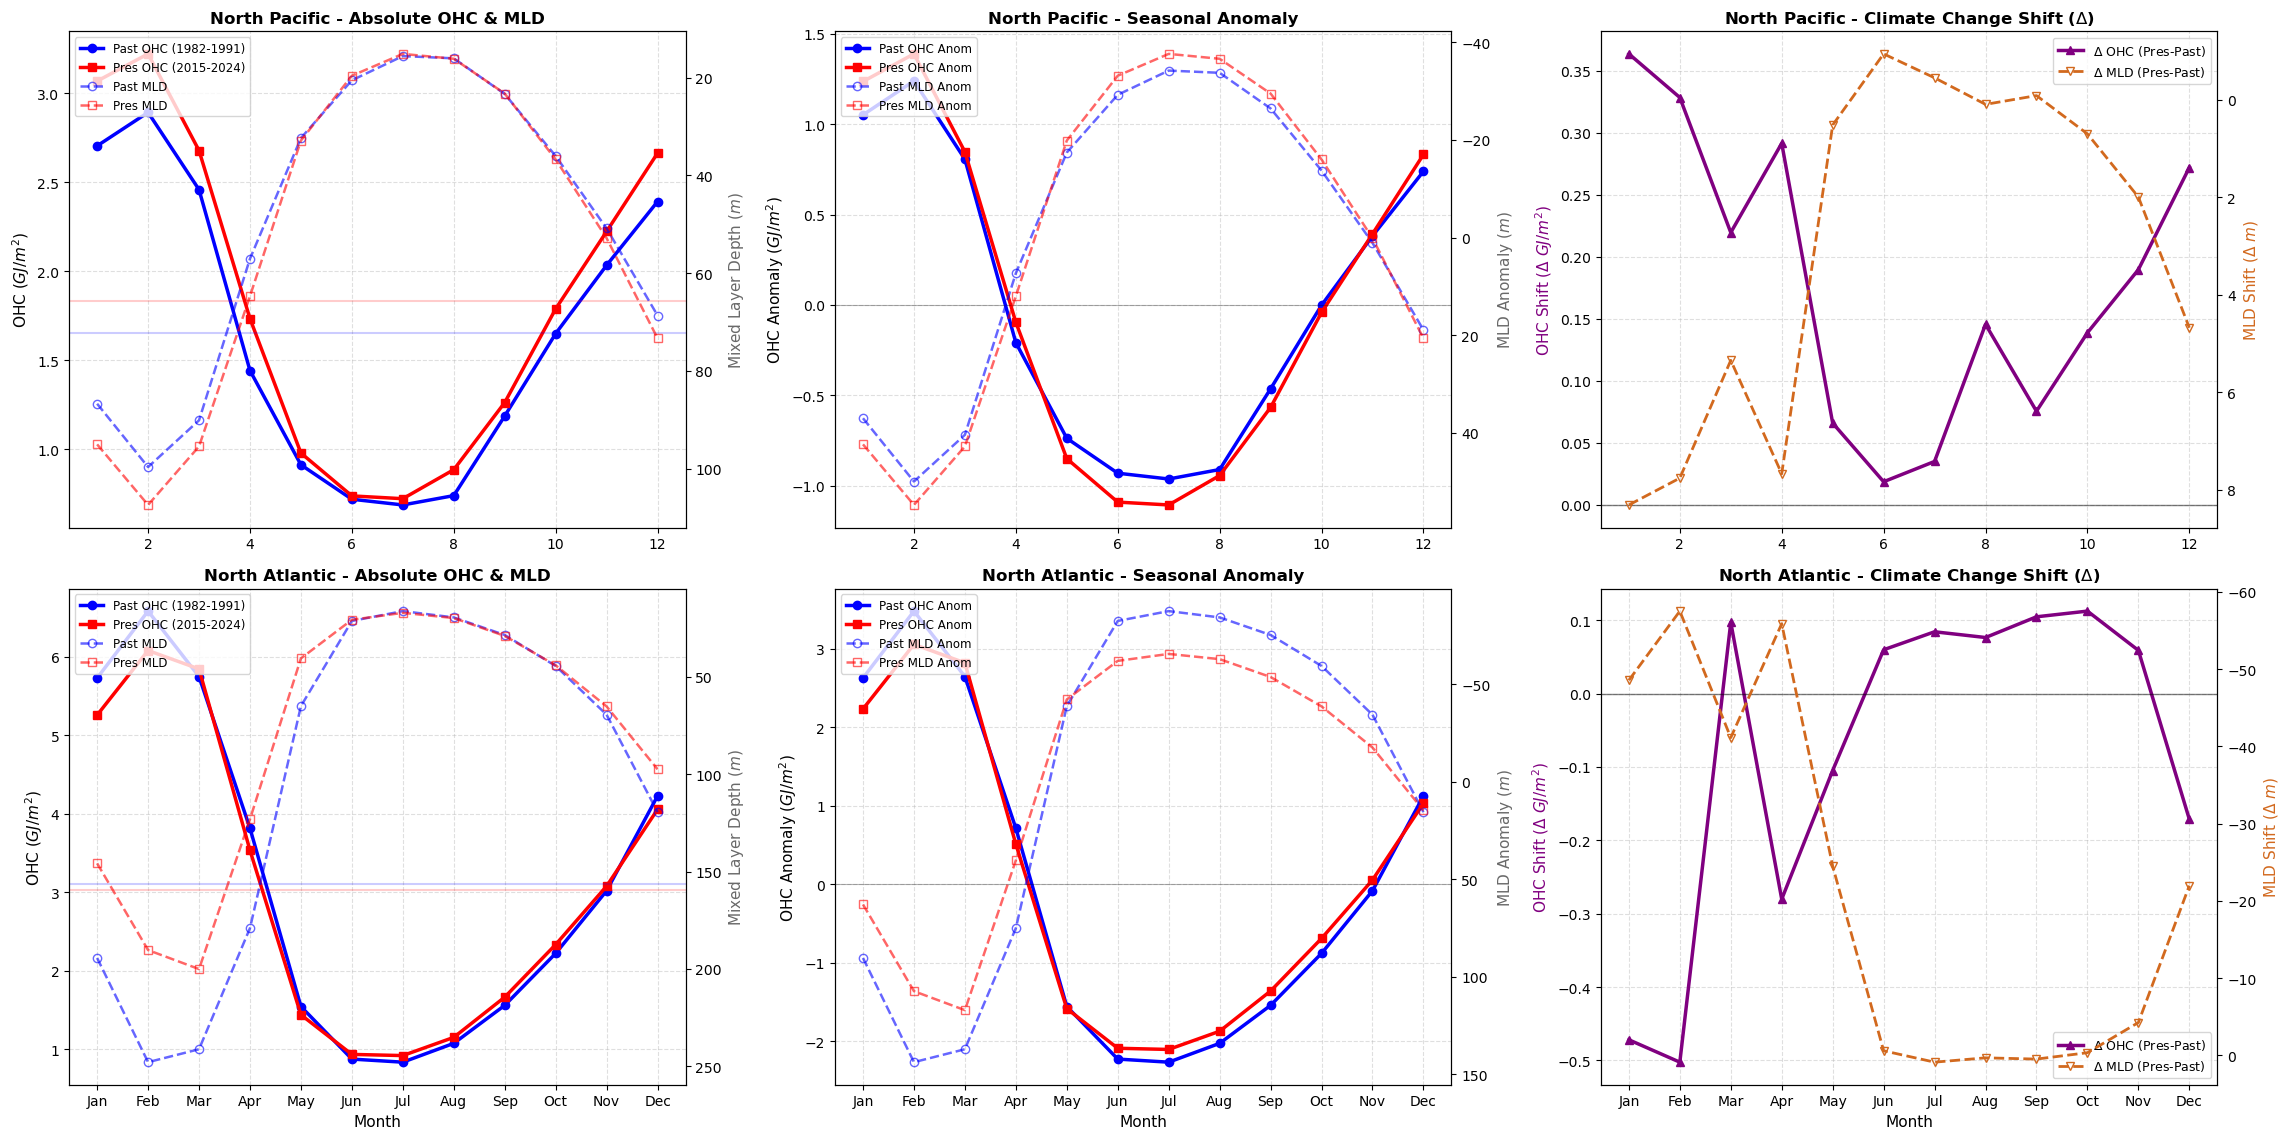

In [15]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================
# 1. Path and Constant Configurations
# ==========================================
root_dir_temp = '/nird/datalake/NS11071K/users/yongyub/ORAS5/potential_temperature'
root_dir_mld = '/nird/datalake/NS11071K/users/yongyub/ORAS5/mixed_layer_depth_0_03'

regions = ['North_Pacific', 'North_Atlantic']

rho0 = 1025.0  # Seawater reference density (kg/m^3)
Cp = 3996.0    # Specific heat capacity of seawater (J/(kg*C))

past_years = range(1982, 1992)      # 1982 ~ 1991 (10 years)
present_years = range(2015, 2025)   # 2015 ~ 2024 (10 years)

def get_dual_file_lists(region_name, years_range):
    """Collects matching file paths for both Potential Temperature and MLD"""
    temp_files = []
    mld_files = []
    
    reg_dir_temp = os.path.join(root_dir_temp, region_name)
    reg_dir_mld = os.path.join(root_dir_mld, region_name)
    
    for yr in years_range:
        temp_pattern = os.path.join(reg_dir_temp, str(yr), f"{region_name}_votemper_1x1_{yr}*.nc")
        mld_pattern = os.path.join(reg_dir_mld, str(yr), f"{region_name}_somxl030_1x1_{yr}*.nc")
        
        temp_files.extend(sorted(glob.glob(temp_pattern)))
        mld_files.extend(sorted(glob.glob(mld_pattern)))
        
    return temp_files, mld_files

# ==========================================
# 2. OHC & MLD Calculation Core Function
# ==========================================
def calculate_ohc_and_mld_seasonality(temp_files, mld_files):
    """Computes both dynamic MLD-bounded OHC and pure MLD depth seasonal cycles"""
    if len(temp_files) == 0 or len(mld_files) == 0:
        raise ValueError("File lists are empty. Please check paths.")

    def drop_duplicate_coords(ds):
        if 'lon' in ds.coords and not ds.indexes['lon'].is_unique:
            _, index = np.unique(ds['lon'], return_index=True)
            ds = ds.isel(lon=sorted(index))
        if 'lat' in ds.coords and not ds.indexes['lat'].is_unique:
            _, index = np.unique(ds['lat'], return_index=True)
            ds = ds.isel(lat=sorted(index))
        return ds

    ds_temp = xr.open_mfdataset(
        temp_files, 
        combine='by_coords', 
        preprocess=drop_duplicate_coords,
        chunks={'time_counter': 1, 'deptht': -1}
    )
    
    target_lon = ds_temp['lon'].values
    target_lat = ds_temp['lat'].values
    target_times = ds_temp['time_counter'].values
    
    print(f"    - Processing and rebuilding {len(mld_files)} MLD files...")
    mld_ds_list = []
    
    for idx, f in enumerate(mld_files):
        ds_single = xr.open_dataset(f)
        ds_single = drop_duplicate_coords(ds_single)
        
        if ds_single['lon'].size == target_lon.size and ds_single['lat'].size == target_lat.size:
            ds_single = ds_single.assign_coords(lon=target_lon, lat=target_lat)
            
        mld_2d_raw = ds_single['somxl030'].values
        if mld_2d_raw.ndim > 2:
            mld_2d_raw = mld_2d_raw[0, :, :] if mld_2d_raw.shape[0] > 0 else np.full((target_lat.size, target_lon.size), np.nan)
            
        mld_anem_2d = xr.DataArray(
            mld_2d_raw,
            dims=['lat', 'lon'],
            coords={'lat': target_lat, 'lon': target_lon}
        )
            
        ds_clean_3d = mld_anem_2d.to_dataset(name='somxl030').expand_dims(time_counter=[target_times[idx]])
        mld_ds_list.append(ds_clean_3d.chunk({'time_counter': 1}))
        
    ds_mld = xr.concat(mld_ds_list, dim='time_counter')
    ds = xr.merge([ds_temp, ds_mld], join='exact')
    
    T = ds['votemper']
    mld = ds['somxl030']
    
    # 2.1 Layer thickness calculation
    depth = ds['deptht'].values
    bounds = np.zeros(len(depth) + 1)
    bounds[1:-1] = (depth[:-1] + depth[1:]) / 2.0
    bounds[0] = 0.0
    bounds[-1] = depth[-1] + (depth[-1] - bounds[-2])
    dz_full = np.diff(bounds)
    
    dz_3d = xr.DataArray(dz_full, dims=['deptht'], coords={'deptht': ds['deptht']})
    z_top = xr.DataArray(bounds[:-1], dims=['deptht'], coords={'deptht': ds['deptht']})
    z_bot = xr.DataArray(bounds[1:], dims=['deptht'], coords={'deptht': ds['deptht']})
    
    cond_inside = z_bot <= mld
    cond_straddle = (z_top < mld) & (z_bot > mld)
    dz_mld_bounded = xr.where(cond_inside, dz_3d, xr.where(cond_straddle, mld - z_top, 0.0))
    
    # 2.2 Vertical Integration for OHC
    ohc_2d = (T * dz_mld_bounded).sum(dim='deptht', skipna=True) * rho0 * Cp
    
    # 2.3 Spatial Mean with Latitude Weighting (For both OHC and MLD)
    weights = np.cos(np.deg2rad(ds['lat']))
    weights.name = "weights"
    
    ohc_timeseries = ohc_2d.weighted(weights).mean(dim=['lat', 'lon'], skipna=True)
    mld_timeseries = mld.weighted(weights).mean(dim=['lat', 'lon'], skipna=True)
    
    # 2.4 Compute Climatological Seasonality
    ohc_seasonality = ohc_timeseries.groupby('time_counter.month').mean(dim='time_counter')
    mld_seasonality = mld_timeseries.groupby('time_counter.month').mean(dim='time_counter')
    
    ohc_seasonality.load()
    mld_seasonality.load()
    ds.close()
    
    return ohc_seasonality, mld_seasonality

# ==========================================
# 3. Processing Data for All Regions
# ==========================================
results = {}

for reg in regions:
    print(f"\n>>> Processing Region: {reg.replace('_', ' ')} ...")
    past_temp, past_mld = get_dual_file_lists(reg, past_years)
    pres_temp, pres_mld = get_dual_file_lists(reg, present_years)
    
    ohc_past, mld_past = calculate_ohc_seasonality_mld_bundle = calculate_ohc_and_mld_seasonality(past_temp, past_mld)
    ohc_present, mld_present = calculate_ohc_seasonality_mld_bundle = calculate_ohc_and_mld_seasonality(pres_temp, pres_mld)
    
    # Scale variables
    past_ohc_gj = ohc_past / 1e9
    pres_ohc_gj = ohc_present / 1e9
    
    results[reg] = {
        'past_ohc': past_ohc_gj, 'pres_ohc': pres_ohc_gj,
        'mean_past_ohc': past_ohc_gj.mean(), 'mean_pres_ohc': pres_ohc_gj.mean(),
        'anom_past_ohc': past_ohc_gj - past_ohc_gj.mean(),
        'anom_pres_ohc': pres_ohc_gj - pres_ohc_gj.mean(),
        
        # MLD Depths
        'past_mld': mld_past, 'pres_mld': mld_present,
        'mean_past_mld': mld_past.mean(), 'mean_pres_mld': mld_present.mean(),
        'anom_past_mld': mld_past - mld_past.mean(),
        'anom_pres_mld': mld_present - mld_present.mean()
    }

# ==========================================
# 4. Render 2-Row x 3-Column Comprehensive Dual-Axis Grid
# ==========================================
print("\n>>> Displaying 2-row x 3-column expanded dual-axis matrix (with Difference column)...")

# Setup 2 rows x 3 columns figure layout
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(23, 11.5))

months_axis = np.arange(1, 13)
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for r_idx, reg in enumerate(regions):
    res = results[reg]
    title_prefix = "North Pacific" if reg == 'North_Pacific' else "North Atlantic"
    
    # Compute baseline differences (Present - Past)
    ohc_diff = res['pres_ohc'] - res['past_ohc']
    mld_diff = res['pres_mld'] - res['past_mld']
    
    # -------------------------------------------------------------
    # Col 1: Absolute Climatological Seasonality
    # -------------------------------------------------------------
    ax_abs = axes[r_idx, 0]
    ax_abs_mld = ax_abs.twinx()
    
    l1 = ax_abs.plot(months_axis, res['past_ohc'], marker='o', color='blue', linewidth=2.5, label='Past OHC (1982-1991)')
    l2 = ax_abs.plot(months_axis, res['pres_ohc'], marker='s', color='red', linewidth=2.5, label='Pres OHC (2015-2024)')
    ax_abs.axhline(res['mean_past_ohc'], color='blue', linestyle='-', alpha=0.2)
    ax_abs.axhline(res['mean_pres_ohc'], color='red', linestyle='-', alpha=0.2)
    
    l3 = ax_abs_mld.plot(months_axis, res['past_mld'], marker='o', mfc='none', color='blue', linestyle='--', linewidth=1.8, alpha=0.6, label='Past MLD')
    l4 = ax_abs_mld.plot(months_axis, res['pres_mld'], marker='s', mfc='none', color='red', linestyle='--', linewidth=1.8, alpha=0.6, label='Pres MLD')
    
    ax_abs.set_title(f"{title_prefix} - Absolute OHC & MLD", fontsize=12, weight='bold')
    ax_abs.set_ylabel('OHC ($GJ / m^2$)', fontsize=11)
    ax_abs_mld.set_ylabel('Mixed Layer Depth ($m$)', fontsize=11, color='dimgray')
    ax_abs_mld.invert_yaxis()
    ax_abs.grid(True, linestyle='--', alpha=0.4)
    
    lns1 = l1 + l2 + l3 + l4
    ax_abs.legend(lns1, [l.get_label() for l in lns1], fontsize=8.5, loc='upper left')
    
    # -------------------------------------------------------------
    # Col 2: Seasonal Anomalies
    # -------------------------------------------------------------
    ax_anom = axes[r_idx, 1]
    ax_anom_mld = ax_anom.twinx()
    
    la1 = ax_anom.plot(months_axis, res['anom_past_ohc'], marker='o', color='blue', linewidth=2.5, label='Past OHC Anom')
    la2 = ax_anom.plot(months_axis, res['anom_pres_ohc'], marker='s', color='red', linewidth=2.5, label='Pres OHC Anom')
    ax_anom.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
    
    la3 = ax_anom_mld.plot(months_axis, res['anom_past_mld'], marker='o', mfc='none', color='blue', linestyle='--', linewidth=1.8, alpha=0.6, label='Past MLD Anom')
    la4 = ax_anom_mld.plot(months_axis, res['anom_pres_mld'], marker='s', mfc='none', color='red', linestyle='--', linewidth=1.8, alpha=0.6, label='Pres MLD Anom')
    
    ax_anom.set_title(f"{title_prefix} - Seasonal Anomaly", fontsize=12, weight='bold')
    ax_anom.set_ylabel('OHC Anomaly ($GJ / m^2$)', fontsize=11)
    ax_anom_mld.set_ylabel('MLD Anomaly ($m$)', fontsize=11, color='dimgray')
    ax_anom_mld.invert_yaxis()
    ax_anom.grid(True, linestyle='--', alpha=0.4)
    
    lns2 = la1 + la2 + la3 + la4
    ax_anom.legend(lns2, [l.get_label() for l in lns2], fontsize=8.5, loc='upper left')

    # -------------------------------------------------------------
    # New Column 3: Decadal Shift / Difference (Present - Past)
    # -------------------------------------------------------------
    ax_diff = axes[r_idx, 2]
    ax_diff_mld = ax_diff.twinx()
    
    # Plot OHC Net Shift (Solid Magenta or DeepPurple line)
    ld1 = ax_diff.plot(months_axis, ohc_diff, marker='^', color='purple', linewidth=2.5, label='$\Delta$ OHC (Pres-Past)')
    ax_diff.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.5)
    
    # Plot MLD Net Shift (Dashed Orange or Brown line)
    ld2 = ax_diff_mld.plot(months_axis, mld_diff, marker='v', mfc='none', color='chocolate', linestyle='--', linewidth=2.0, label='$\Delta$ MLD (Pres-Past)')
    
    ax_diff.set_title(f"{title_prefix} - Climate Change Shift ($\Delta$)", fontsize=12, weight='bold')
    ax_diff.set_ylabel('OHC Shift ($\Delta$ $GJ / m^2$)', fontsize=11, color='purple')
    ax_diff_mld.set_ylabel('MLD Shift ($\Delta$ $m$)', fontsize=11, color='chocolate')
    
    # Match depth axis convention: negative delta means shoaling (shallower), positive means deepening
    ax_diff_mld.invert_yaxis() 
    ax_diff.grid(True, linestyle='--', alpha=0.4)
    
    # Combine Legends for Difference Column
    lns3 = ld1 + ld2
    ax_diff.legend(lns3, [l.get_label() for l in lns3], fontsize=9, loc='best')

# Standardize bottom X-axis configurations for all three columns
for col_idx in range(3):
    axes[1, col_idx].set_xlabel('Month', fontsize=11)
    axes[1, col_idx].set_xticks(months_axis)
    axes[1, col_idx].set_xticklabels(month_labels)

plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import xarray as xr

def calculate_asymmetry_indices(ohc_seasonality):
    """
    Performs Fourier Analysis on 12-month OHC climatology 
    to extract A1, A2, phi1, phi2 and compute |DAI| and |PAI|.
    """
    # 1. Ensure data is a 1D array of length 12
    data = ohc_seasonality.values.squeeze()
    if len(data) != 12:
        raise ValueError("Input seasonality must have exactly 12 monthly values.")
        
    # 2. Perform Discrete Fourier Transform (DFT)
    dft_coeffs = np.fft.fft(data)
    
    # N=12 normalization factor (FFT in numpy requires 2/N for non-zero frequencies)
    # Harmonic 1 (Annual cycle): index 1
    # Harmonic 2 (Semi-annual cycle): index 2
    h1 = dft_coeffs[1] * (2.0 / 12.0)
    h2 = dft_coeffs[2] * (2.0 / 12.0)
    
    # 3. Extract Amplitudes (A1, A2)
    A1 = np.abs(h1)
    A2 = np.abs(h2)
    
    # 4. Extract Phases (phi1, phi2) in radians
    phi1 = -np.angle(h1)
    phi2 = -np.angle(h2)
    
    # 5. Compute Asymmetry Phase Parameter (Theta = 2*phi1 - phi2)
    theta = 2 * phi1 - phi2
    
    # 6. Calculate Magnitude Indices
    amplitude_ratio = A2 / A1
    DAI_mag = amplitude_ratio * np.abs(np.sin(theta))
    PAI_mag = amplitude_ratio * np.abs(np.cos(theta))
    
    return {
        'A1': A1, 'A2': A2, 
        'phi1': np.degrees(phi1) % 360, 'phi2': np.degrees(phi2) % 360, 
        'DAI_mag': DAI_mag, 'PAI_mag': PAI_mag
    }

# ==========================================
# Run Asymmetry Analysis for Both Regions (Mixed Layer OHC)
# ==========================================
print("=== Computing Asymmetry Indices (|DAI| & |PAI|) for Mixed Layer Above OHC ===")

# Loop through the pre-computed MLD results from the previous step
for reg in ['North_Pacific', 'North_Atlantic']:
    reg_label = reg.replace('_', ' ')
    res = results[reg]
    
    # Fixed: Updated dictionary keys from 'past_gj'/'present_gj' to 'past_ohc'/'pres_ohc'
    idx_past = calculate_asymmetry_indices(res['past_ohc'] * 1e9)     
    idx_present = calculate_asymmetry_indices(res['pres_ohc'] * 1e9)
    
    # Print Structured Results Table per Region
    print("\n" + "="*55)
    print(f"  [ REGION: {reg_label.upper()} (MIXED LAYER OHC) ]")
    print("="*55)
    print(f"{'Metric':<15} | {'Past (1982-1991)':<18} | {'Present (2015-2024)':<18}")
    print("-"*55)
    print(f"{'A1 (Annual)':<15} | {idx_past['A1']/1e9:16.4f} | {idx_present['A1']/1e9:16.4f} GJ/m^2")
    print(f"{'A2 (Semi-Ann)':<15} | {idx_past['A2']/1e9:16.4f} | {idx_present['A2']/1e9:16.4f} GJ/m^2")
    print(f"{'A2 / A1 Ratio':<15} | {idx_past['A2']/idx_past['A1']:16.4f} | {idx_present['A2']/idx_present['A1']:16.4f}")
    print(f"{'phi1 (deg)':<15} | {idx_past['phi1']:16.2f}° | {idx_present['phi1']:16.2f}°")
    print(f"{'phi2 (deg)':<15} | {idx_past['phi2']:16.2f}° | {idx_present['phi2']:16.2f}°")
    print("-"*55)
    print(f"{'|DAI| Magnitude':<15} | \033[1;34m{idx_past['DAI_mag']:16.4f}\033[0m | \033[1;31m{idx_present['DAI_mag']:16.4f}\033[0m")
    print(f"{'|PAI| Magnitude':<15} | \033[1;34m{idx_past['PAI_mag']:16.4f}\033[0m | \033[1;31m{idx_present['PAI_mag']:16.4f}\033[0m")
    print("="*55)

=== Computing Asymmetry Indices (|DAI| & |PAI|) for Mixed Layer Above OHC ===

  [ REGION: NORTH PACIFIC (MIXED LAYER OHC) ]
Metric          | Past (1982-1991)   | Present (2015-2024)
-------------------------------------------------------
A1 (Annual)     |           1.0873 |           1.2280 GJ/m^2
A2 (Semi-Ann)   |           0.1867 |           0.2213 GJ/m^2
A2 / A1 Ratio   |           0.1717 |           0.1802
phi1 (deg)      |             1.43° |             2.32°
phi2 (deg)      |            70.46° |            70.18°
-------------------------------------------------------
|DAI| Magnitude |           0.1588 |           0.1640
|PAI| Magnitude |           0.0654 |           0.0746

  [ REGION: NORTH ATLANTIC (MIXED LAYER OHC) ]
Metric          | Past (1982-1991)   | Present (2015-2024)
-------------------------------------------------------
A1 (Annual)     |           2.7006 |           2.4774 GJ/m^2
A2 (Semi-Ann)   |           0.7821 |           0.7586 GJ/m^2
A2 / A1 Ratio   |      

>>> Computing Annual A2/A1 Ratio Timeseries for Mixed Layer Above OHC (1982-2024)...
  - Processing Region: North Pacific
  - Processing Region: North Atlantic

>>> Plotting unified A2/A1 ratio timeseries for Mixed Layer Above OHC...


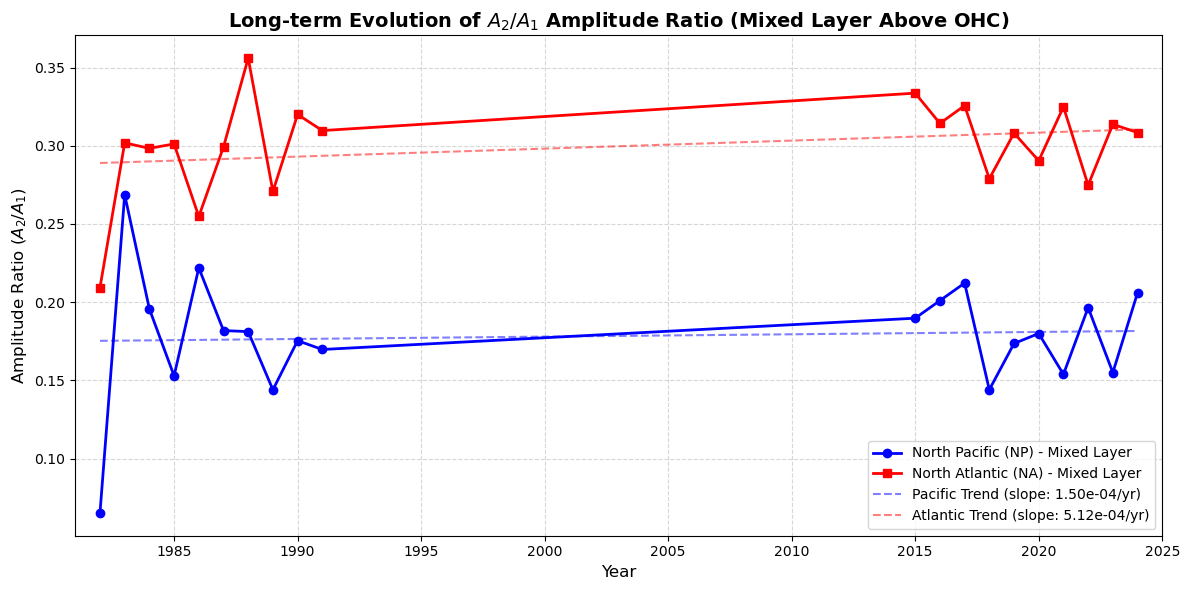

In [18]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================
# 1. Path and Multi-Year Configurations
# ==========================================
root_dir_temp = '/nird/datalake/NS11071K/users/yongyub/ORAS5/potential_temperature'
root_dir_mld = '/nird/datalake/NS11071K/users/yongyub/ORAS5/mixed_layer_depth_0_03'

regions = ['North_Pacific', 'North_Atlantic']
all_years = range(1982, 2025)  # 1982 ~ 2024 (43 years)

# Physical constants for Ocean Heat Content
rho0 = 1025.0
Cp = 3996.0

def get_single_year_dual_files(region_name, target_year):
    """Collects exactly 12 monthly files for both Potential Temperature and MLD"""
    reg_dir_temp = os.path.join(root_dir_temp, region_name)
    reg_dir_mld = os.path.join(root_dir_mld, region_name)
    
    temp_pattern = os.path.join(reg_dir_temp, str(target_year), f"{region_name}_votemper_1x1_{target_year}*.nc")
    mld_pattern = os.path.join(reg_dir_mld, str(target_year), f"{region_name}_somxl030_1x1_{target_year}*.nc")
    
    return sorted(glob.glob(temp_pattern)), sorted(glob.glob(mld_pattern))

# Initialize storage for timeseries
ratio_timeseries = {reg: [] for reg in regions}
valid_years = {reg: [] for reg in regions}

# ==========================================
# 2. Annual Loop for Fourier Ratio Extraction (Mixed Layer OHC)
# ==========================================
print(">>> Computing Annual A2/A1 Ratio Timeseries for Mixed Layer Above OHC (1982-2024)...")

def drop_duplicate_coords(ds):
    if 'lon' in ds.coords and not ds.indexes['lon'].is_unique:
        _, index = np.unique(ds['lon'], return_index=True)
        ds = ds.isel(lon=sorted(index))
    if 'lat' in ds.coords and not ds.indexes['lat'].is_unique:
        _, index = np.unique(ds['lat'], return_index=True)
        ds = ds.isel(lat=sorted(index))
    return ds

for reg in regions:
    print(f"  - Processing Region: {reg.replace('_', ' ')}")
    
    for yr in all_years:
        temp_files, mld_files = get_single_year_dual_files(reg, yr)
        
        # Strictly guarantee 12-month alignment for both variables within the target year
        if len(temp_files) != 12 or len(mld_files) != 12:
            continue
            
        # 2.1 Load Temperature core template framework
        ds_temp = xr.open_mfdataset(temp_files, combine='by_coords', preprocess=drop_duplicate_coords, chunks={'time_counter': 1, 'deptht': -1})
        
        target_lon = ds_temp['lon'].values
        target_lat = ds_temp['lat'].values
        target_times = ds_temp['time_counter'].values
        
        # 2.2 Rebuild MLD 12 months sequentially to eliminate any size-0 or tracking coordinate corruptions
        mld_ds_list = []
        for idx, f in enumerate(mld_files):
            ds_single = xr.open_dataset(f)
            ds_single = drop_duplicate_coords(ds_single)
            
            if ds_single['lon'].size == target_lon.size and ds_single['lat'].size == target_lat.size:
                ds_single = ds_single.assign_coords(lon=target_lon, lat=target_lat)
                
            mld_2d_raw = ds_single['somxl030'].values
            if mld_2d_raw.ndim > 2:
                mld_2d_raw = mld_2d_raw[0, :, :] if mld_2d_raw.shape[0] > 0 else np.full((target_lat.size, target_lon.size), np.nan)
                
            mld_anem_2d = xr.DataArray(
                mld_2d_raw, dims=['lat', 'lon'], coords={'lat': target_lat, 'lon': target_lon}
            )
            ds_clean_3d = mld_anem_2d.to_dataset(name='somxl030').expand_dims(time_counter=[target_times[idx]])
            mld_ds_list.append(ds_clean_3d.chunk({'time_counter': 1}))
            
        ds_mld = xr.concat(mld_ds_list, dim='time_counter')
        
        # Combine temperature and custom mapped MLD grid
        ds = xr.merge([ds_temp, ds_mld], join='exact')
        
        T = ds['votemper']
        mld = ds['somxl030']
        
        # 2.3 Layer thickness calculation
        depth = ds['deptht'].values
        bounds = np.zeros(len(depth) + 1)
        bounds[1:-1] = (depth[:-1] + depth[1:]) / 2.0
        bounds[0] = 0.0
        bounds[-1] = depth[-1] + (depth[-1] - bounds[-2])
        dz_full = np.diff(bounds)
        
        dz_3d = xr.DataArray(dz_full, dims=['deptht'], coords={'deptht': ds['deptht']})
        z_top = xr.DataArray(bounds[:-1], dims=['deptht'], coords={'deptht': ds['deptht']})
        z_bot = xr.DataArray(bounds[1:], dims=['deptht'], coords={'deptht': ds['deptht']})
        
        cond_inside = z_bot <= mld
        cond_straddle = (z_top < mld) & (z_bot > mld)
        dz_mld_bounded = xr.where(cond_inside, dz_3d, xr.where(cond_straddle, mld - z_top, 0.0))
        
        # 2.4 Vertical Integration & Area Weighting
        ohc_2d = (T * dz_mld_bounded).sum(dim='deptht', skipna=True) * rho0 * Cp
        weights = np.cos(np.deg2rad(ds['lat']))
        weights.name = "weights"
        
        ohc_1d = ohc_2d.weighted(weights).mean(dim=['lat', 'lon'], skipna=True).load()
        ds.close()
        
        # 2.5 1D Fourier Mapping along the single year track
        data_12months = ohc_1d.values.squeeze()
        dft_coeffs = np.fft.fft(data_12months)
        
        A1 = np.abs(dft_coeffs[1] * (2.0 / 12.0))
        A2 = np.abs(dft_coeffs[2] * (2.0 / 12.0))
        
        if A1 > 0:
            ratio_timeseries[reg].append(A2 / A1)
            valid_years[reg].append(yr)

# ==========================================
# 3. Single-Panel Comparison Plot
# ==========================================
print("\n>>> Plotting unified A2/A1 ratio timeseries for Mixed Layer Above OHC...")
plt.figure(figsize=(12, 6))

# Plot North Pacific (NP)
plt.plot(valid_years['North_Pacific'], ratio_timeseries['North_Pacific'], 
         marker='o', color='blue', linewidth=2, label='North Pacific (NP) - Mixed Layer')

# Plot North Atlantic (NA)
plt.plot(valid_years['North_Atlantic'], ratio_timeseries['North_Atlantic'], 
         marker='s', color='red', linewidth=2, label='North Atlantic (NA) - Mixed Layer')

# Add linear trendlines to see long-term structural changes
for reg, color in zip(regions, ['blue', 'red']):
    x = np.array(valid_years[reg])
    y = np.array(ratio_timeseries[reg])
    if len(x) > 0:
        slope, intercept = np.polyfit(x, y, 1)
        reg_label = 'Pacific' if 'Pacific' in reg else 'Atlantic'
        plt.plot(x, slope*x + intercept, color=color, linestyle='--', alpha=0.5, 
                 label=f"{reg_label} Trend (slope: {slope:.2e}/yr)")

# Plot adjustments
plt.title('Long-term Evolution of $A_2 / A_1$ Amplitude Ratio (Mixed Layer Above OHC)', fontsize=14, weight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Amplitude Ratio ($A_2 / A_1$)', fontsize=12)
plt.xlim(1981, 2025)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.show()

In [19]:
import os
import glob
import numpy as np
import xarray as xr

# ==========================================
# 1. Path and Data Configurations (MLD Above - North Pacific)
# ==========================================
print(">>> Collecting file paths for North Pacific (MLD-bounded)...")
past_temp_pac, past_mld_pac = get_dual_file_lists('North_Pacific', past_years)
pres_temp_pac, pres_mld_pac = get_dual_file_lists('North_Pacific', present_years)

print(f"  - Aligned Past files   [POT: {len(past_temp_pac)} | MLD: {len(past_mld_pac)}]")
print(f"  - Aligned Present files [POT: {len(pres_temp_pac)} | MLD: {len(pres_mld_pac)}]")

def drop_duplicate_coords(ds):
    if 'lon' in ds.coords and not ds.indexes['lon'].is_unique:
        _, index = np.unique(ds['lon'], return_index=True)
        ds = ds.isel(lon=sorted(index))
    if 'lat' in ds.coords and not ds.indexes['lat'].is_unique:
        _, index = np.unique(ds['lat'], return_index=True)
        ds = ds.isel(lat=sorted(index))
    return ds

# Load standard 4D Temperature Framework to lock horizontal grids
ds_past_temp = xr.open_mfdataset(past_temp_pac, combine='by_coords', preprocess=drop_duplicate_coords, chunks={'time_counter': 1, 'deptht': -1})
ds_pres_temp = xr.open_mfdataset(pres_temp_pac, combine='by_coords', preprocess=drop_duplicate_coords, chunks={'time_counter': 1, 'deptht': -1})

target_lon_pac = ds_past_temp['lon'].values
target_lat_pac = ds_past_temp['lat'].values
ny_pac, nx_pac = len(target_lat_pac), len(target_lon_pac)

# -----------------------------------------------------------------------------
# [핵심 격자 동기화 엔진] MLD 2D 파일들을 루프로 안전하게 추출하여 3D 시계열 결합
# -----------------------------------------------------------------------------
def rebuild_mld_dataset(mld_file_list, reference_temp_ds):
    times = reference_temp_ds['time_counter'].values
    mld_list = []
    for idx, f in enumerate(mld_file_list):
        ds_s = xr.open_dataset(f)
        ds_s = drop_duplicate_coords(ds_s)
        if ds_s['lon'].size == target_lon_pac.size and ds_s['lat'].size == target_lat_pac.size:
            ds_s = ds_s.assign_coords(lon=target_lon_pac, lat=target_lat_pac)
            
        mld_raw = ds_s['somxl030'].values
        if mld_raw.ndim > 2:
            mld_raw = mld_raw[0, :, :] if mld_raw.shape[0] > 0 else np.full((ny_pac, nx_pac), np.nan)
            
        mld_da = xr.DataArray(mld_raw, dims=['lat', 'lon'], coords={'lat': target_lat_pac, 'lon': target_lon_pac})
        mld_list.append(mld_da.to_dataset(name='somxl030').expand_dims(time_counter=[times[idx]]))
    return xr.concat(mld_list, dim='time_counter').chunk({'time_counter': 1})

print("  - Building clean 3D MLD time-series for Past & Present horizons...")
ds_past_mld = rebuild_mld_dataset(past_mld_pac, ds_past_temp)
ds_pres_mld = rebuild_mld_dataset(pres_mld_pac, ds_pres_temp)

# Exact merge to avoid coordinate offsets dropping data cells
ds_past = xr.merge([ds_past_temp, ds_past_mld], join='exact')
ds_present = xr.merge([ds_pres_temp, ds_pres_mld], join='exact')

# -----------------------------------------------------------------------------
# 2. Vectorized Integration over Dynamic Mixed Layer Depth
# -----------------------------------------------------------------------------
def compute_mld_ohc_climatology(ds_unified):
    T = ds_unified['votemper']
    mld = ds_unified['somxl030']
    
    depth = ds_unified['deptht'].values
    bounds = np.zeros(len(depth) + 1)
    bounds[1:-1] = (depth[:-1] + depth[1:]) / 2.0
    bounds[0] = 0.0
    bounds[-1] = depth[-1] + (depth[-1] - bounds[-2])
    dz_full = np.diff(bounds)
    
    dz_3d = xr.DataArray(dz_full, dims=['deptht'], coords={'deptht': ds_unified['deptht']})
    z_top = xr.DataArray(bounds[:-1], dims=['deptht'], coords={'deptht': ds_unified['deptht']})
    z_bot = xr.DataArray(bounds[1:], dims=['deptht'], coords={'deptht': ds_unified['deptht']})
    
    cond_inside = z_bot <= mld
    cond_straddle = (z_top < mld) & (z_bot > mld)
    dz_bounded = xr.where(cond_inside, dz_3d, xr.where(cond_straddle, mld - z_top, 0.0))
    
    # 2D Ocean Heat Content at each coordinate grid and time point
    ohc_2d = (T * dz_bounded).sum(dim='deptht', skipna=True) * rho0 * Cp
    
    # Generate 12-month climatology grids (Shape: 12 x lat x lon)
    clim_grid = ohc_2d.groupby('time_counter.month').mean(dim='time_counter').load()
    return clim_grid

print("  - Integrating OHC over active mixed layer depths (Past)...")
clim_past_pac = compute_mld_ohc_climatology(ds_past)
print("  - Integrating OHC over active mixed layer depths (Present)...")
clim_present_pac = compute_mld_ohc_climatology(ds_present)

ds_past.close()
ds_present.close()

# -----------------------------------------------------------------------------
# 3. Grid-Point FFT Function
# -----------------------------------------------------------------------------
def compute_asymmetry_maps_pac(clim_grid, ny, nx):
    """Vectorized calculation of |DAI| and |PAI| maps optimized for MLD-OHC grids"""
    data_3d = clim_grid.values
    data_flat = data_3d.reshape(12, -1)
    
    land_mask = np.isnan(data_flat.mean(axis=0))
    data_flat_filled = np.nan_to_num(data_flat, nan=0.0)
    
    dft_coeffs = np.fft.fft(data_flat_filled, axis=0)
    
    h1 = dft_coeffs[1, :] * (2.0 / 12.0)
    h2 = dft_coeffs[2, :] * (2.0 / 12.0)
    
    A1 = np.abs(h1)
    A2 = np.abs(h2)
    phi1 = -np.angle(h1)
    phi2 = -np.angle(h2)
    theta = 2 * phi1 - phi2
    
    with np.errstate(divide='ignore', invalid='ignore'):
        amp_ratio = A2 / A1
        dai = amp_ratio * np.abs(np.sin(theta))
        pai = amp_ratio * np.abs(np.cos(theta))
        
    dai[land_mask] = np.nan
    pai[land_mask] = np.nan
    return dai.reshape(ny, nx), pai.reshape(ny, nx)

print("\n>>> Executing spatial Fourier transform maps for North Pacific Mixed Layer OHC...")
dai_past_pac, pai_past_pac = compute_asymmetry_maps_pac(clim_past_pac, ny_pac, nx_pac)
dai_present_pac, pai_present_pac = compute_asymmetry_maps_pac(clim_present_pac, ny_pac, nx_pac)

dai_diff_pac = dai_present_pac - dai_past_pac
pai_diff_pac = pai_present_pac - pai_past_pac

print("=== Pacific Grid-Point FFT MLD Computations Completed Successfully! ===")

>>> Collecting file paths for North Pacific (MLD-bounded)...
  - Aligned Past files   [POT: 120 | MLD: 120]
  - Aligned Present files [POT: 120 | MLD: 120]
  - Building clean 3D MLD time-series for Past & Present horizons...
  - Integrating OHC over active mixed layer depths (Past)...
  - Integrating OHC over active mixed layer depths (Present)...

>>> Executing spatial Fourier transform maps for North Pacific Mixed Layer OHC...
=== Pacific Grid-Point FFT MLD Computations Completed Successfully! ===


>>> Visualizing 3x2 Asymmetry Spatial Matrix for North Pacific (Mixed Layer Above OHC)...


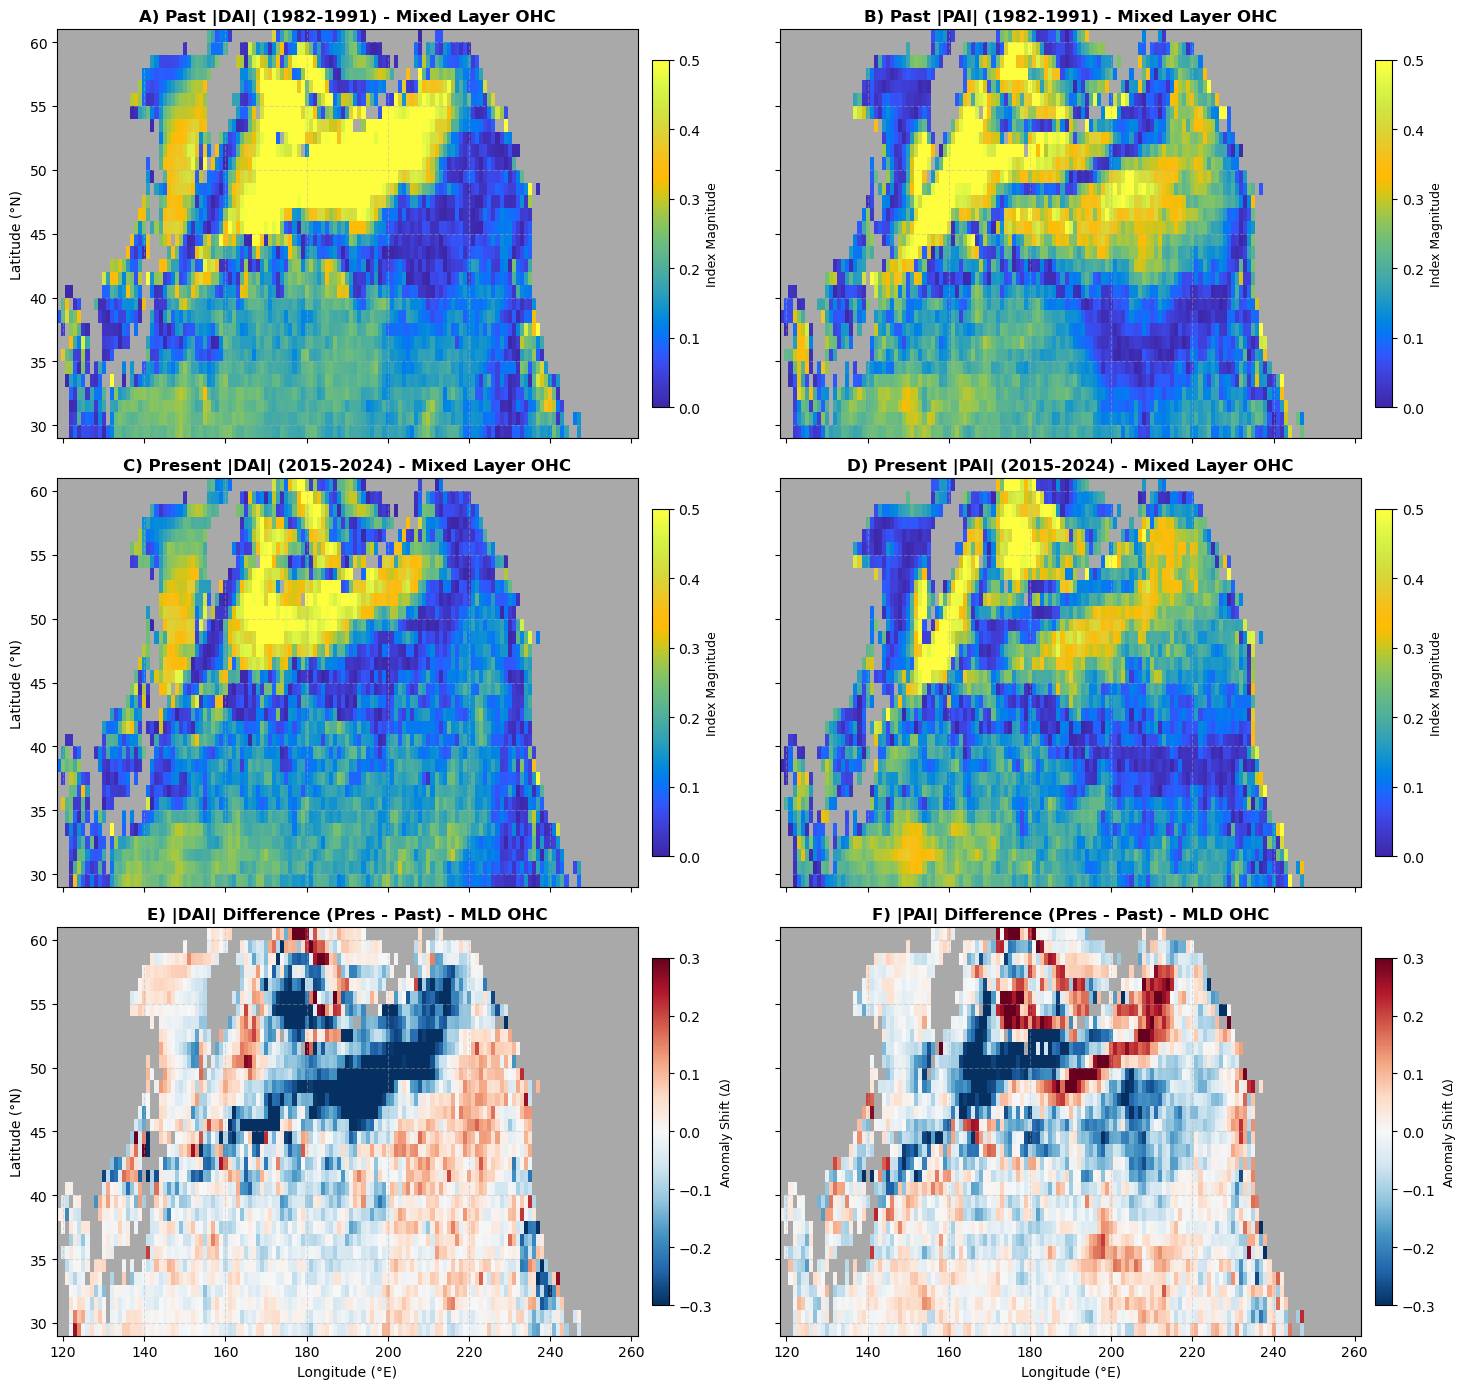

In [20]:
print(">>> Visualizing 3x2 Asymmetry Spatial Matrix for North Pacific (Mixed Layer Above OHC)...")

from matplotlib.colors import LinearSegmentedColormap

# 2.1 Re-map Custom Parula Colormap Frame
parula_data = [
    [0.2422, 0.1504, 0.6603], [0.2444, 0.1793, 0.7107], [0.2464, 0.2062, 0.7621],
    [0.2464, 0.2336, 0.8166], [0.2406, 0.2631, 0.8735], [0.2243, 0.2974, 0.9328],
    [0.1925, 0.3372, 0.9852], [0.1345, 0.3842, 0.9996], [0.0637, 0.4337, 0.9822],
    [0.0150, 0.4795, 0.9429], [0.0076, 0.5204, 0.8936], [0.0381, 0.5557, 0.8430],
    [0.0886, 0.5855, 0.7960], [0.1437, 0.6111, 0.7523], [0.1966, 0.6338, 0.7115],
    [0.2448, 0.6548, 0.6724], [0.2878, 0.6749, 0.6336], [0.3275, 0.6946, 0.5941],
    [0.3662, 0.7137, 0.5529], [0.4068, 0.7317, 0.5085], [0.4526, 0.7481, 0.4593],
    [0.5061, 0.7621, 0.4035], [0.5694, 0.7725, 0.3396], [0.6433, 0.7785, 0.2666],
    [0.7275, 0.7789, 0.1856], [0.8193, 0.7719, 0.1065], [0.9120, 0.7561, 0.0453],
    [0.9873, 0.7384, 0.0248], [0.9959, 0.7337, 0.0415], [0.9806, 0.7445, 0.0766],
    [0.9507, 0.7628, 0.1171], [0.9150, 0.7854, 0.1557], [0.8809, 0.8105, 0.1895],
    [0.8533, 0.8369, 0.2173], [0.8339, 0.8637, 0.2384], [0.8242, 0.8904, 0.2530],
    [0.8258, 0.9163, 0.2618], [0.8398, 0.9404, 0.2657], [0.8664, 0.9619, 0.2657],
    [0.9044, 0.9800, 0.2625], [0.9515, 0.9933, 0.2570], [0.9965, 0.9977, 0.2443]
]
parula_cmap = LinearSegmentedColormap.from_list('parula', parula_data, N=256)
diff_cmap = 'RdBu_r'

# 2.2 Main Figure Framing
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=True, sharey=True)

# Build accurate mesh grid coordinates matching processed Pacific array
lon_grid_pac, lat_grid_pac = np.meshgrid(target_lon_pac, target_lat_pac)

vmax_idx = 0.5    
vmax_diff = 0.3

# Subplot rendering mapping matching MLD structures
plots_config = [
    # Row 1: Past State (Mixed Layer Above)
    {'data': dai_past_pac,    'ax': axes[0, 0], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'A) Past |DAI| (1982-1991) - Mixed Layer OHC'},
    {'data': pai_past_pac,    'ax': axes[0, 1], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'B) Past |PAI| (1982-1991) - Mixed Layer OHC'},
    # Row 2: Present State (Mixed Layer Above)
    {'data': dai_present_pac, 'ax': axes[1, 0], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'C) Present |DAI| (2015-2024) - Mixed Layer OHC'},
    {'data': pai_present_pac, 'ax': axes[1, 1], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'D) Present |PAI| (2015-2024) - Mixed Layer OHC'},
    # Row 3: Climate Change Shift (Present - Past)
    {'data': dai_diff_pac,    'ax': axes[2, 0], 'cmap': diff_cmap,   'vmin': -vmax_diff, 'vmax': vmax_diff, 'title': 'E) |DAI| Difference (Pres - Past) - MLD OHC'},
    {'data': pai_diff_pac,    'ax': axes[2, 1], 'cmap': diff_cmap,   'vmin': -vmax_diff, 'vmax': vmax_diff, 'title': 'F) |PAI| Difference (Pres - Past) - MLD OHC'}
]

for p in plots_config:
    ax = p['ax']
    mesh = ax.pcolormesh(lon_grid_pac, lat_grid_pac, p['data'], cmap=p['cmap'], vmin=p['vmin'], vmax=p['vmax'], shading='auto')
    ax.set_title(p['title'], fontsize=12, weight='bold')
    
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, shrink=0.85)
    if 'Difference' in p['title']:
        cbar.set_label('Anomaly Shift ($\Delta$)', fontsize=9)
    else:
        cbar.set_label('Index Magnitude', fontsize=9)

# Standardize axis decorations for the entire matrix frame
for ax in axes.flatten():
    ax.set_facecolor('darkgray')  # Highlights landmask areas cleanly
    ax.grid(True, linestyle='--', alpha=0.4)

for row in range(3):
    axes[row, 0].set_ylabel('Latitude (°N)', fontsize=10)
for col in range(2):
    axes[2, col].set_xlabel('Longitude (°E)', fontsize=10)

plt.tight_layout()
plt.show()

In [21]:
import os
import glob
import numpy as np
import xarray as xr

# ==========================================
# 1. Multi-Year Path and Domain Setup (MLD Bounded - North Pacific)
# ==========================================
print(">>> Preparing multi-year grid-point trend analysis for North Pacific (MLD-bounded)...")
all_years = range(1982, 2025)  # 1982 ~ 2024 (43 years)

# 1.1 Extract baseline configurations using the first year's files
sample_temp_files, _ = get_single_year_dual_files('North_Pacific', 1982)
ds_template = xr.open_dataset(sample_temp_files[0])

def drop_duplicate_coords(ds):
    if 'lon' in ds.coords and not ds.indexes['lon'].is_unique:
        _, index = np.unique(ds['lon'], return_index=True)
        ds = ds.isel(lon=sorted(index))
    if 'lat' in ds.coords and not ds.indexes['lat'].is_unique:
        _, index = np.unique(ds['lat'], return_index=True)
        ds = ds.isel(lat=sorted(index))
    return ds

ds_template = drop_duplicate_coords(ds_template)
target_lon_pac = ds_template['lon'].values
target_lat_pac = ds_template['lat'].values
ny_pac, nx_pac = len(target_lat_pac), len(target_lon_pac)
ds_template.close()

# Allocate 3D arrays to store annual maps: (Years, Lat, Lon)
num_years = len(all_years)
annual_dai_3d = np.full((num_years, ny_pac, nx_pac), np.nan)
annual_pai_3d = np.full((num_years, ny_pac, nx_pac), np.nan)

# ==========================================
# 2. Annual Loop for Fourier Grid Mapping
# ==========================================
for y_idx, yr in enumerate(all_years):
    temp_files, mld_files = get_single_year_dual_files('North_Pacific', yr)
    
    if len(temp_files) != 12 or len(mld_files) != 12:
        print(f"  - Year {yr}: [Skip] Missing months.")
        continue
        
    print(f"  - Extracting annual asymmetry grids for year: {yr}...")
    ds_temp_yr = xr.open_mfdataset(temp_files, combine='by_coords', preprocess=drop_duplicate_coords, chunks={'time_counter': 1, 'deptht': -1})
    target_times = ds_temp_yr['time_counter'].values
    
    # 2.1 Rebuild MLD 12 months sequentially to stabilize dimensions and match the core temperature grid
    mld_ds_list = []
    for idx, f in enumerate(mld_files):
        ds_single = xr.open_dataset(f)
        ds_single = drop_duplicate_coords(ds_single)
        
        if ds_single['lon'].size == target_lon_pac.size and ds_single['lat'].size == target_lat_pac.size:
            ds_single = ds_single.assign_coords(lon=target_lon_pac, lat=target_lat_pac)
            
        mld_2d_raw = ds_single['somxl030'].values
        if mld_2d_raw.ndim > 2:
            mld_2d_raw = mld_2d_raw[0, :, :] if mld_2d_raw.shape[0] > 0 else np.full((ny_pac, nx_pac), np.nan)
            
        mld_anem_2d = xr.DataArray(
            mld_2d_raw, dims=['lat', 'lon'], coords={'lat': target_lat_pac, 'lon': target_lon_pac}
        )
        ds_clean_3d = mld_anem_2d.to_dataset(name='somxl030').expand_dims(time_counter=[target_times[idx]])
        mld_ds_list.append(ds_clean_3d.chunk({'time_counter': 1}))
        
    ds_mld_yr = xr.concat(mld_ds_list, dim='time_counter')
    ds_yr = xr.merge([ds_temp_yr, ds_mld_yr], join='exact')
    
    T = ds_yr['votemper']
    mld = ds_yr['somxl030']
    
    # 2.2 Layer thickness (dz) calculation based on dynamic MLD mapping
    depth = ds_yr['deptht'].values
    bounds = np.zeros(len(depth) + 1)
    bounds[1:-1] = (depth[:-1] + depth[1:]) / 2.0
    bounds[0] = 0.0
    bounds[-1] = depth[-1] + (depth[-1] - bounds[-2])
    dz_full = np.diff(bounds)
    
    dz_3d = xr.DataArray(dz_full, dims=['deptht'], coords={'deptht': ds_yr['deptht']})
    z_top = xr.DataArray(bounds[:-1], dims=['deptht'], coords={'deptht': ds_yr['deptht']})
    z_bot = xr.DataArray(bounds[1:], dims=['deptht'], coords={'deptht': ds_yr['deptht']})
    
    cond_inside = z_bot <= mld
    cond_straddle = (z_top < mld) & (z_bot > mld)
    dz_mld_bounded = xr.where(cond_inside, dz_3d, xr.where(cond_straddle, mld - z_top, 0.0))
    
    # 2D OHC calculation over the active mixed layer depth framework
    ohc_2d_12months = (T * dz_mld_bounded).sum(dim='deptht', skipna=True).load() * rho0 * Cp
    ds_yr.close()
    
    # 2.3 Vectorized 1D FFT along months axis (axis=0)
    data_flat = ohc_2d_12months.values.reshape(12, -1)
    land_mask = np.isnan(data_flat.mean(axis=0))
    data_filled = np.nan_to_num(data_flat, nan=0.0)
    
    dft_coeffs = np.fft.fft(data_filled, axis=0)
    h1 = dft_coeffs[1, :] * (2.0 / 12.0)
    h2 = dft_coeffs[2, :] * (2.0 / 12.0)
    
    A1, A2 = np.abs(h1), np.abs(h2)
    phi1, phi2 = -np.angle(h1), -np.angle(h2)
    theta = 2 * phi1 - phi2
    
    with np.errstate(divide='ignore', invalid='ignore'):
        amp_ratio = A2 / A1
        dai_flat = amp_ratio * np.abs(np.sin(theta))
        pai_flat = amp_ratio * np.abs(np.cos(theta))
        
    dai_flat[land_mask] = np.nan
    pai_flat[land_mask] = np.nan
    
    # Store results into the multi-year spatial matrix framework
    annual_dai_3d[y_idx, :, :] = dai_flat.reshape(ny_pac, nx_pac)
    annual_pai_3d[y_idx, :, :] = pai_flat.reshape(ny_pac, nx_pac)

# ==========================================
# 3. Vectorized Linear Regression (Robust Trend extraction)
# ==========================================
print("\n>>> Computing pixel-by-pixel linear trends across 43 years...")
years_arr = np.array(all_years)

dai_flat_ts = annual_dai_3d.reshape(num_years, -1)
pai_flat_ts = annual_pai_3d.reshape(num_years, -1)

dai_trend_flat = np.full(dai_flat_ts.shape[1], np.nan)
pai_trend_flat = np.full(pai_flat_ts.shape[1], np.nan)

for p_idx in range(dai_flat_ts.shape[1]):
    y_dai = dai_flat_ts[:, p_idx]
    y_pai = pai_flat_ts[:, p_idx]
    
    valid_dai = ~np.isnan(y_dai)
    valid_pai = ~np.isnan(y_pai)
    
    if np.sum(valid_dai) >= 5:  
        dai_trend_flat[p_idx] = np.polyfit(years_arr[valid_dai], y_dai[valid_dai], 1)[0]
    if np.sum(valid_pai) >= 5:
        pai_trend_flat[p_idx] = np.polyfit(years_arr[valid_pai], y_pai[valid_pai], 1)[0]

# Reshape trend arrays back to 2D standard maps
dai_trend_pac = dai_trend_flat.reshape(ny_pac, nx_pac)
pai_trend_pac = pai_trend_flat.reshape(ny_pac, nx_pac)

print(f"  - Max DAI Trend found: {np.nanmax(dai_trend_pac):.4e}")
print(f"  - Min DAI Trend found: {np.nanmin(dai_trend_pac):.4e}")
print("=== Long-term Trend Calculation Complete! ===")
print("Variables generated: 'dai_trend_pac' and 'pai_trend_pac' (unit: /year)")

>>> Preparing multi-year grid-point trend analysis for North Pacific (MLD-bounded)...
  - Extracting annual asymmetry grids for year: 1982...
  - Extracting annual asymmetry grids for year: 1983...
  - Extracting annual asymmetry grids for year: 1984...
  - Extracting annual asymmetry grids for year: 1985...
  - Extracting annual asymmetry grids for year: 1986...
  - Extracting annual asymmetry grids for year: 1987...
  - Extracting annual asymmetry grids for year: 1988...
  - Extracting annual asymmetry grids for year: 1989...
  - Extracting annual asymmetry grids for year: 1990...
  - Extracting annual asymmetry grids for year: 1991...
  - Year 1992: [Skip] Missing months.
  - Year 1993: [Skip] Missing months.
  - Year 1994: [Skip] Missing months.
  - Year 1995: [Skip] Missing months.
  - Year 1996: [Skip] Missing months.
  - Year 1997: [Skip] Missing months.
  - Year 1998: [Skip] Missing months.
  - Year 1999: [Skip] Missing months.
  - Year 2000: [Skip] Missing months.
  - Year 200

>>> Visualizing 1x2 Long-term Trend Matrix for |DAI| and |PAI| (Mixed Layer Above OHC)...


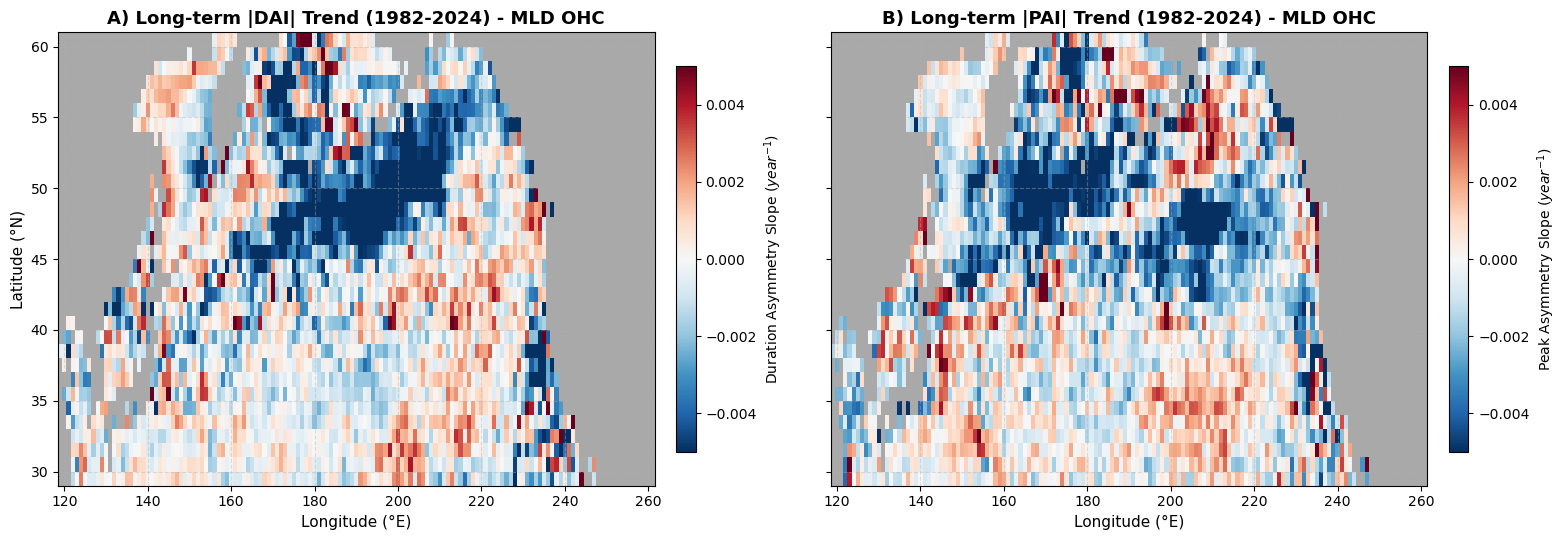

In [22]:
# ==========================================
# 4. Render 1x2 Matrix Panel for Long-term Trends Only (Mixed Layer Above)
# ==========================================
print(">>> Visualizing 1x2 Long-term Trend Matrix for |DAI| and |PAI| (Mixed Layer Above OHC)...")

trend_cmap = 'RdBu_r'

# Setup 1-row, 2-column subplot figure
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5.5), sharex=True, sharey=True)
lon_grid_pac, lat_grid_pac = np.meshgrid(target_lon_pac, target_lat_pac)

# Unified Range Setup for Linear Slope Analysis
vmax_trend = 0.005  # Captures trend scales up to +/- 0.005 per year gracefully

plots_config = [
    {
        'data': dai_trend_pac,   
        'ax': axes[0], 
        'title': 'A) Long-term |DAI| Trend (1982-2024) - MLD OHC',
        'label': 'Duration Asymmetry Slope ($year^{-1}$)'
    },
    {
        'data': pai_trend_pac,   
        'ax': axes[1], 
        'title': 'B) Long-term |PAI| Trend (1982-2024) - MLD OHC',
        'label': 'Peak Asymmetry Slope ($year^{-1}$)'
    }
]

for p in plots_config:
    ax = p['ax']
    mesh = ax.pcolormesh(
        lon_grid_pac, lat_grid_pac, p['data'], 
        cmap=trend_cmap, vmin=-vmax_trend, vmax=vmax_trend, shading='auto'
    )
    ax.set_title(p['title'], fontsize=13, weight='bold')
    
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.03, shrink=0.85)
    cbar.set_label(p['label'], fontsize=10)

# Standardize axis decorations for the 1x2 block frame
for ax in axes:
    ax.set_facecolor('darkgray')  # Highlights landmask areas beautifully
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlabel('Longitude (°E)', fontsize=11)

# Apply y-label only to the leftmost axis to keep the figure neat
axes[0].set_ylabel('Latitude (°N)', fontsize=11)

plt.tight_layout()
plt.show()

In [23]:
import os
import glob
import numpy as np
import xarray as xr

# ==========================================
# 1. Path and Data Configurations (MLD Above - North Atlantic)
# ==========================================
print(">>> Collecting file paths for North Atlantic (MLD-bounded)...")
past_temp_atl, past_mld_atl = get_dual_file_lists('North_Atlantic', past_years)
pres_temp_atl, pres_mld_atl = get_dual_file_lists('North_Atlantic', present_years)

print(f"  - Aligned Atlantic Past files   [POT: {len(past_temp_atl)} | MLD: {len(past_mld_atl)}]")
print(f"  - Aligned Atlantic Present files [POT: {len(pres_temp_atl)} | MLD: {len(pres_mld_atl)}]")

def drop_duplicate_coords(ds):
    if 'lon' in ds.coords and not ds.indexes['lon'].is_unique:
        _, index = np.unique(ds['lon'], return_index=True)
        ds = ds.isel(lon=sorted(index))
    if 'lat' in ds.coords and not ds.indexes['lat'].is_unique:
        _, index = np.unique(ds['lat'], return_index=True)
        ds = ds.isel(lat=sorted(index))
    return ds

# Load standard 4D Temperature Framework to lock horizontal grids for Atlantic
ds_past_temp_atl = xr.open_mfdataset(past_temp_atl, combine='by_coords', preprocess=drop_duplicate_coords, chunks={'time_counter': 1, 'deptht': -1})
ds_pres_temp_atl = xr.open_mfdataset(pres_temp_atl, combine='by_coords', preprocess=drop_duplicate_coords, chunks={'time_counter': 1, 'deptht': -1})

target_lon_atl = ds_past_temp_atl['lon'].values
target_lat_atl = ds_past_temp_atl['lat'].values
ny_atl, nx_atl = len(target_lat_pac:=target_lat_atl), len(target_lon_pac:=target_lon_atl)

# -----------------------------------------------------------------------------
# [핵심 격자 동기화 엔진] MLD 2D 파일들을 루프로 안전하게 추출하여 3D 시계열 결합 (Atlantic)
# -----------------------------------------------------------------------------
def rebuild_mld_dataset_atl(mld_file_list, reference_temp_ds):
    times = reference_temp_ds['time_counter'].values
    mld_list = []
    for idx, f in enumerate(mld_file_list):
        ds_s = xr.open_dataset(f)
        ds_s = drop_duplicate_coords(ds_s)
        if ds_s['lon'].size == target_lon_atl.size and ds_s['lat'].size == target_lat_atl.size:
            ds_s = ds_s.assign_coords(lon=target_lon_atl, lat=target_lat_atl)
            
        mld_raw = ds_s['somxl030'].values
        if mld_raw.ndim > 2:
            mld_raw = mld_raw[0, :, :] if mld_raw.shape[0] > 0 else np.full((ny_atl, nx_atl), np.nan)
            
        mld_da = xr.DataArray(mld_raw, dims=['lat', 'lon'], coords={'lat': target_lat_atl, 'lon': target_lon_atl})
        mld_list.append(mld_da.to_dataset(name='somxl030').expand_dims(time_counter=[times[idx]]))
    return xr.concat(mld_list, dim='time_counter').chunk({'time_counter': 1})

print("  - Building clean 3D MLD time-series for Atlantic...")
ds_past_mld_atl = rebuild_mld_dataset_atl(past_mld_atl, ds_past_temp_atl)
ds_pres_mld_atl = rebuild_mld_dataset_atl(pres_mld_atl, ds_pres_temp_atl)

# Exact merge to avoid coordinate offsets dropping data cells
ds_past_atl_final = xr.merge([ds_past_temp_atl, ds_past_mld_atl], join='exact')
ds_present_atl_final = xr.merge([ds_pres_temp_atl, ds_pres_mld_atl], join='exact')

# -----------------------------------------------------------------------------
# 2. Vectorized Integration over Dynamic Mixed Layer Depth
# -----------------------------------------------------------------------------
def compute_mld_ohc_climatology_atl(ds_unified):
    T = ds_unified['votemper']
    mld = ds_unified['somxl030']
    
    depth = ds_unified['deptht'].values
    bounds = np.zeros(len(depth) + 1)
    bounds[1:-1] = (depth[:-1] + depth[1:]) / 2.0
    bounds[0] = 0.0
    bounds[-1] = depth[-1] + (depth[-1] - bounds[-2])
    dz_full = np.diff(bounds)
    
    dz_3d = xr.DataArray(dz_full, dims=['deptht'], coords={'deptht': ds_unified['deptht']})
    z_top = xr.DataArray(bounds[:-1], dims=['deptht'], coords={'deptht': ds_unified['deptht']})
    z_bot = xr.DataArray(bounds[1:], dims=['deptht'], coords={'deptht': ds_unified['deptht']})
    
    cond_inside = z_bot <= mld
    cond_straddle = (z_top < mld) & (z_bot > mld)
    dz_bounded = xr.where(cond_inside, dz_3d, xr.where(cond_straddle, mld - z_top, 0.0))
    
    # 2D Ocean Heat Content calculation
    ohc_2d = (T * dz_bounded).sum(dim='deptht', skipna=True) * rho0 * Cp
    
    # Generate 12-month climatology grids (Shape: 12 x lat x lon)
    clim_grid = ohc_2d.groupby('time_counter.month').mean(dim='time_counter').load()
    return clim_grid

print("  - Integrating OHC over active mixed layer depths (Atlantic Past)...")
clim_past_atl = compute_mld_ohc_climatology_atl(ds_past_atl_final)
print("  - Integrating OHC over active mixed layer depths (Atlantic Present)...")
clim_present_atl = compute_mld_ohc_climatology_atl(ds_present_atl_final)

ds_past_atl_final.close()
ds_present_atl_final.close()

# -----------------------------------------------------------------------------
# 3. Grid-Point FFT Function (Atlantic)
# -----------------------------------------------------------------------------
def compute_asymmetry_maps_atl(clim_grid, ny, nx):
    """Vectorized calculation of |DAI| and |PAI| maps optimized for MLD-OHC grids"""
    data_3d = clim_grid.values
    data_flat = data_3d.reshape(12, -1)
    
    land_mask = np.isnan(data_flat.mean(axis=0))
    data_flat_filled = np.nan_to_num(data_flat, nan=0.0)
    
    dft_coeffs = np.fft.fft(data_flat_filled, axis=0)
    
    h1 = dft_coeffs[1, :] * (2.0 / 12.0)
    h2 = dft_coeffs[2, :] * (2.0 / 12.0)
    
    A1 = np.abs(h1)
    A2 = np.abs(h2)
    phi1 = -np.angle(h1)
    phi2 = -np.angle(h2)
    theta = 2 * phi1 - phi2
    
    with np.errstate(divide='ignore', invalid='ignore'):
        amp_ratio = A2 / A1
        dai = amp_ratio * np.abs(np.sin(theta))
        pai = amp_ratio * np.abs(np.cos(theta))
        
    dai[land_mask] = np.nan
    pai[land_mask] = np.nan
    return dai.reshape(ny, nx), pai.reshape(ny, nx)

print("\n>>> Executing spatial Fourier transform maps for North Atlantic Mixed Layer OHC...")
dai_past_atl, pai_past_atl = compute_asymmetry_maps_atl(clim_past_atl, ny_atl, nx_atl)
dai_present_atl, pai_present_atl = compute_asymmetry_maps_atl(clim_present_atl, ny_atl, nx_atl)

dai_diff_atl = dai_present_atl - dai_past_atl
pai_diff_atl = pai_present_atl - pai_past_atl

print("=== Atlantic Grid-Point FFT MLD Computations Completed Successfully! ===")

>>> Collecting file paths for North Atlantic (MLD-bounded)...
  - Aligned Atlantic Past files   [POT: 120 | MLD: 120]
  - Aligned Atlantic Present files [POT: 120 | MLD: 120]
  - Building clean 3D MLD time-series for Atlantic...
  - Integrating OHC over active mixed layer depths (Atlantic Past)...
  - Integrating OHC over active mixed layer depths (Atlantic Present)...

>>> Executing spatial Fourier transform maps for North Atlantic Mixed Layer OHC...
=== Atlantic Grid-Point FFT MLD Computations Completed Successfully! ===


>>> Visualizing 3x2 Asymmetry Spatial Matrix for North Atlantic (Mixed Layer Above OHC)...


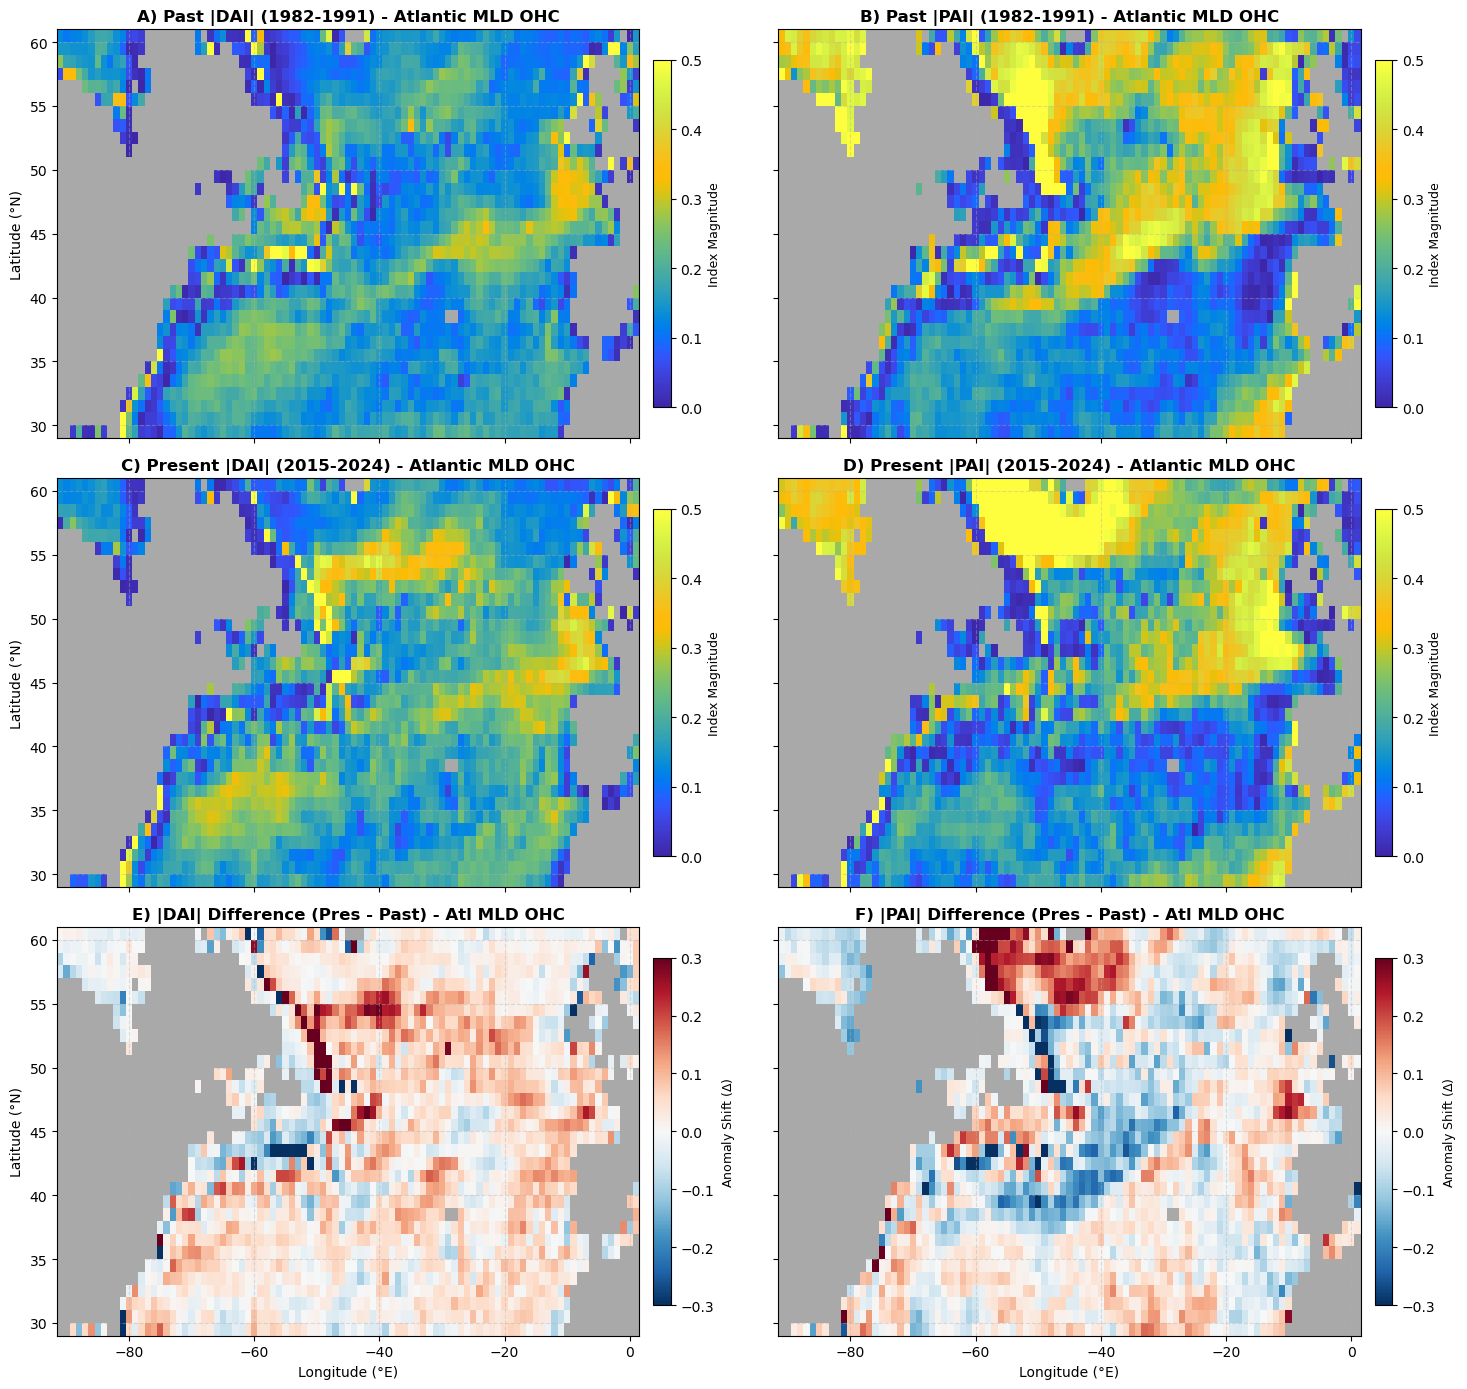

In [24]:
print(">>> Visualizing 3x2 Asymmetry Spatial Matrix for North Atlantic (Mixed Layer Above OHC)...")

# Reuse existing parula_cmap from prior notebooks cells
diff_cmap = 'RdBu_r'

# Main Figure Framing
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=True, sharey=True)

# Build accurate mesh grid coordinates matching processed Atlantic array
lon_grid_atl, lat_grid_atl = np.meshgrid(target_lon_atl, target_lat_atl)

vmax_idx = 0.5    
vmax_diff = 0.3

# Subplot rendering mapping matching MLD structures for North Atlantic
plots_config = [
    # Row 1: Past State (Mixed Layer Above)
    {'data': dai_past_atl,    'ax': axes[0, 0], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'A) Past |DAI| (1982-1991) - Atlantic MLD OHC'},
    {'data': pai_past_atl,    'ax': axes[0, 1], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'B) Past |PAI| (1982-1991) - Atlantic MLD OHC'},
    # Row 2: Present State (Mixed Layer Above)
    {'data': dai_present_atl, 'ax': axes[1, 0], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'C) Present |DAI| (2015-2024) - Atlantic MLD OHC'},
    {'data': pai_present_atl, 'ax': axes[1, 1], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'D) Present |PAI| (2015-2024) - Atlantic MLD OHC'},
    # Row 3: Climate Change Shift (Present - Past)
    {'data': dai_diff_atl,    'ax': axes[2, 0], 'cmap': diff_cmap,   'vmin': -vmax_diff, 'vmax': vmax_diff, 'title': 'E) |DAI| Difference (Pres - Past) - Atl MLD OHC'},
    {'data': pai_diff_atl,    'ax': axes[2, 1], 'cmap': diff_cmap,   'vmin': -vmax_diff, 'vmax': vmax_diff, 'title': 'F) |PAI| Difference (Pres - Past) - Atl MLD OHC'}
]

for p in plots_config:
    ax = p['ax']
    mesh = ax.pcolormesh(lon_grid_atl, lat_grid_atl, p['data'], cmap=p['cmap'], vmin=p['vmin'], vmax=p['vmax'], shading='auto')
    ax.set_title(p['title'], fontsize=12, weight='bold')
    
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, shrink=0.85)
    if 'Difference' in p['title']:
        cbar.set_label('Anomaly Shift ($\Delta$)', fontsize=9)
    else:
        cbar.set_label('Index Magnitude', fontsize=9)

# Standardize axis decorations for the entire matrix frame
for ax in axes.flatten():
    ax.set_facecolor('darkgray')  # Highlights landmask areas cleanly
    ax.grid(True, linestyle='--', alpha=0.4)

for row in range(3):
    axes[row, 0].set_ylabel('Latitude (°N)', fontsize=10)
for col in range(2):
    axes[2, col].set_xlabel('Longitude (°E)', fontsize=10)

plt.tight_layout()
plt.show()

In [25]:
import os
import glob
import numpy as np
import xarray as xr

# ==========================================
# 1. Multi-Year Path and Domain Setup (MLD Bounded - North Atlantic)
# ==========================================
print(">>> Preparing multi-year grid-point trend analysis for North Atlantic (MLD-bounded)...")
all_years = range(1982, 2025)  # 1982 ~ 2024 (43 years)

# 1.1 Extract baseline configurations using the Atlantic template file
sample_temp_files_atl, _ = get_single_year_dual_files('North_Atlantic', 1982)
ds_template_atl = xr.open_dataset(sample_temp_files_atl[0])

def drop_duplicate_coords(ds):
    if 'lon' in ds.coords and not ds.indexes['lon'].is_unique:
        _, index = np.unique(ds['lon'], return_index=True)
        ds = ds.isel(lon=sorted(index))
    if 'lat' in ds.coords and not ds.indexes['lat'].is_unique:
        _, index = np.unique(ds['lat'], return_index=True)
        ds = ds.isel(lat=sorted(index))
    return ds

ds_template_atl = drop_duplicate_coords(ds_template_atl)
target_lon_atl = ds_template_atl['lon'].values
target_lat_atl = ds_template_atl['lat'].values
ny_atl, nx_atl = len(target_lat_atl), len(target_lon_atl)
ds_template_atl.close()

# Allocate 3D arrays to store annual maps: (Years, Lat, Lon) for Atlantic
num_years = len(all_years)
annual_dai_3d_atl = np.full((num_years, ny_atl, nx_atl), np.nan)
annual_pai_3d_atl = np.full((num_years, ny_atl, nx_atl), np.nan)

# ==========================================
# 2. Annual Loop for Fourier Grid Mapping (Atlantic)
# ==========================================
for y_idx, yr in enumerate(all_years):
    temp_files, mld_files = get_single_year_dual_files('North_Atlantic', yr)
    
    if len(temp_files) != 12 or len(mld_files) != 12:
        print(f"  - Year {yr}: [Skip] Missing months for Atlantic.")
        continue
        
    print(f"  - Extracting annual asymmetry grids for Atlantic - year: {yr}...")
    ds_temp_yr = xr.open_mfdataset(temp_files, combine='by_coords', preprocess=drop_duplicate_coords, chunks={'time_counter': 1, 'deptht': -1})
    target_times = ds_temp_yr['time_counter'].values
    
    # 2.1 Rebuild MLD 12 months sequentially to stabilize dimensions for Atlantic grid
    mld_ds_list = []
    for idx, f in enumerate(mld_files):
        ds_single = xr.open_dataset(f)
        ds_single = drop_duplicate_coords(ds_single)
        
        if ds_single['lon'].size == target_lon_atl.size and ds_single['lat'].size == target_lat_atl.size:
            ds_single = ds_single.assign_coords(lon=target_lon_atl, lat=target_lat_atl)
            
        mld_2d_raw = ds_single['somxl030'].values
        if mld_2d_raw.ndim > 2:
            mld_2d_raw = mld_2d_raw[0, :, :] if mld_2d_raw.shape[0] > 0 else np.full((ny_atl, nx_atl), np.nan)
            
        mld_anem_2d = xr.DataArray(
            mld_2d_raw, dims=['lat', 'lon'], coords={'lat': target_lat_atl, 'lon': target_lon_atl}
        )
        ds_clean_3d = mld_anem_2d.to_dataset(name='somxl030').expand_dims(time_counter=[target_times[idx]])
        mld_ds_list.append(ds_clean_3d.chunk({'time_counter': 1}))
        
    ds_mld_yr = xr.concat(mld_ds_list, dim='time_counter')
    ds_yr = xr.merge([ds_temp_yr, ds_mld_yr], join='exact')
    
    T = ds_yr['votemper']
    mld = ds_yr['somxl030']
    
    # 2.2 Layer thickness (dz) calculation based on dynamic MLD mapping
    depth = ds_yr['deptht'].values
    bounds = np.zeros(len(depth) + 1)
    bounds[1:-1] = (depth[:-1] + depth[1:]) / 2.0
    bounds[0] = 0.0
    bounds[-1] = depth[-1] + (depth[-1] - bounds[-2])
    dz_full = np.diff(bounds)
    
    dz_3d = xr.DataArray(dz_full, dims=['deptht'], coords={'deptht': ds_yr['deptht']})
    z_top = xr.DataArray(bounds[:-1], dims=['deptht'], coords={'deptht': ds_yr['deptht']})
    z_bot = xr.DataArray(bounds[1:], dims=['deptht'], coords={'deptht': ds_yr['deptht']})
    
    cond_inside = z_bot <= mld
    cond_straddle = (z_top < mld) & (z_bot > mld)
    dz_mld_bounded = xr.where(cond_inside, dz_3d, xr.where(cond_straddle, mld - z_top, 0.0))
    
    # 2D OHC calculation over the active mixed layer depth framework
    ohc_2d_12months = (T * dz_mld_bounded).sum(dim='deptht', skipna=True).load() * rho0 * Cp
    ds_yr.close()
    
    # 2.3 Vectorized 1D FFT along months axis (axis=0)
    data_flat = ohc_2d_12months.values.reshape(12, -1)
    land_mask = np.isnan(data_flat).all(axis=0)
    data_filled = np.nan_to_num(data_flat, nan=0.0)
    
    dft_coeffs = np.fft.fft(data_filled, axis=0)
    h1 = dft_coeffs[1, :] * (2.0 / 12.0)
    h2 = dft_coeffs[2, :] * (2.0 / 12.0)
    
    A1, A2 = np.abs(h1), np.abs(h2)
    phi1, phi2 = -np.angle(h1), -np.angle(h2)
    theta = 2 * phi1 - phi2
    
    with np.errstate(divide='ignore', invalid='ignore'):
        amp_ratio = A2 / A1
        dai_flat = amp_ratio * np.abs(np.sin(theta))
        pai_flat = amp_ratio * np.abs(np.cos(theta))
        
    dai_flat[land_mask] = np.nan
    pai_flat[land_mask] = np.nan
    
    # Store results into the multi-year spatial matrix framework for Atlantic
    annual_dai_3d_atl[y_idx, :, :] = dai_flat.reshape(ny_atl, nx_atl)
    annual_pai_3d_atl[y_idx, :, :] = pai_flat.reshape(ny_atl, nx_atl)

# ==========================================
# 3. Vectorized Linear Regression (Robust Trend extraction)
# ==========================================
print("\n>>> Computing pixel-by-pixel linear trends across 43 years for Atlantic...")
years_arr = np.array(all_years)

dai_flat_ts_atl = annual_dai_3d_atl.reshape(num_years, -1)
pai_flat_ts_atl = annual_pai_3d_atl.reshape(num_years, -1)

dai_trend_flat_atl = np.full(dai_flat_ts_atl.shape[1], np.nan)
pai_trend_flat_atl = np.full(pai_flat_ts_atl.shape[1], np.nan)

for p_idx in range(dai_flat_ts_atl.shape[1]):
    y_dai = dai_flat_ts_atl[:, p_idx]
    y_pai = pai_flat_ts_atl[:, p_idx]
    
    valid_dai = ~np.isnan(y_dai)
    valid_pai = ~np.isnan(y_pai)
    
    if np.sum(valid_dai) >= 5:  
        dai_trend_flat_atl[p_idx] = np.polyfit(years_arr[valid_dai], y_dai[valid_dai], 1)[0]
    if np.sum(valid_pai) >= 5:
        pai_trend_flat_atl[p_idx] = np.polyfit(years_arr[valid_pai], y_pai[valid_pai], 1)[0]

# Reshape trend arrays back to 2D standard maps for Atlantic
dai_trend_atl = dai_trend_flat_atl.reshape(ny_atl, nx_atl)
pai_trend_atl = pai_trend_flat_atl.reshape(ny_atl, nx_atl)

print(f"  - Max DAI Atlantic Trend found: {np.nanmax(dai_trend_atl):.4e}")
print(f"  - Min DAI Atlantic Trend found: {np.nanmin(dai_trend_atl):.4e}")
print(f"  - Non-NaN Grid Count (Atlantic): {np.count_nonzero(~np.isnan(dai_trend_atl))} / {ny_atl * nx_atl}")
print("=== Long-term Atlantic Trend Calculation Complete! ===")
print("Variables generated: 'dai_trend_atl' and 'pai_trend_atl' (unit: /year)")

>>> Preparing multi-year grid-point trend analysis for North Atlantic (MLD-bounded)...
  - Extracting annual asymmetry grids for Atlantic - year: 1982...
  - Extracting annual asymmetry grids for Atlantic - year: 1983...
  - Extracting annual asymmetry grids for Atlantic - year: 1984...
  - Extracting annual asymmetry grids for Atlantic - year: 1985...
  - Extracting annual asymmetry grids for Atlantic - year: 1986...
  - Extracting annual asymmetry grids for Atlantic - year: 1987...
  - Extracting annual asymmetry grids for Atlantic - year: 1988...
  - Extracting annual asymmetry grids for Atlantic - year: 1989...
  - Extracting annual asymmetry grids for Atlantic - year: 1990...
  - Extracting annual asymmetry grids for Atlantic - year: 1991...
  - Year 1992: [Skip] Missing months for Atlantic.
  - Year 1993: [Skip] Missing months for Atlantic.
  - Year 1994: [Skip] Missing months for Atlantic.
  - Year 1995: [Skip] Missing months for Atlantic.
  - Year 1996: [Skip] Missing months fo

>>> Visualizing 1x2 Long-term Trend Matrix for North Atlantic (|DAI| & |PAI| - MLD OHC)...


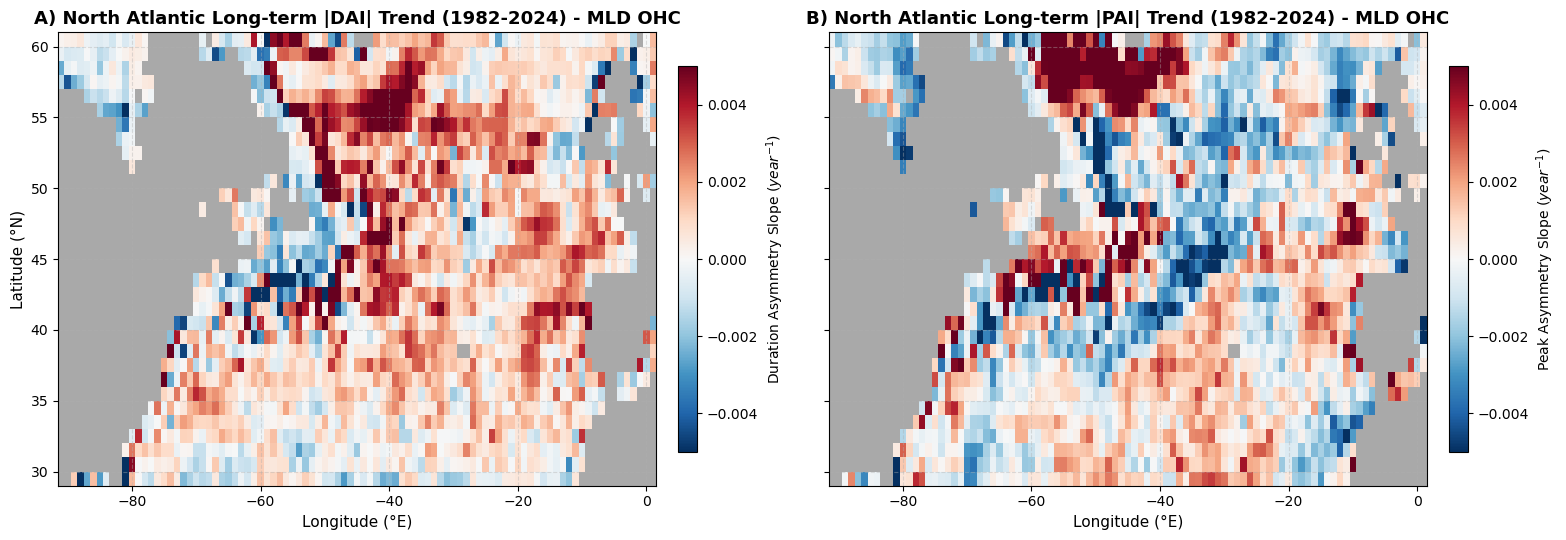

In [26]:
# ==========================================
# 4. Render 1x2 Matrix Panel for North Atlantic Long-term Trends Only
# ==========================================
print(">>> Visualizing 1x2 Long-term Trend Matrix for North Atlantic (|DAI| & |PAI| - MLD OHC)...")

trend_cmap = 'RdBu_r'

# Setup 1-row, 2-column subplot figure
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5.5), sharex=True, sharey=True)
lon_grid_atl, lat_grid_atl = np.meshgrid(target_lon_atl, target_lat_atl)

# Unified Range Setup for Linear Slope Analysis
vmax_trend = 0.005  # Captures trend scales up to +/- 0.005 per year gracefully

plots_config_atl = [
    {
        'data': dai_trend_atl,   
        'ax': axes[0], 
        'title': 'A) North Atlantic Long-term |DAI| Trend (1982-2024) - MLD OHC',
        'label': 'Duration Asymmetry Slope ($year^{-1}$)'
    },
    {
        'data': pai_trend_atl,   
        'ax': axes[1], 
        'title': 'B) North Atlantic Long-term |PAI| Trend (1982-2024) - MLD OHC',
        'label': 'Peak Asymmetry Slope ($year^{-1}$)'
    }
]

for p in plots_config_atl:
    ax = p['ax']
    mesh = ax.pcolormesh(
        lon_grid_atl, lat_grid_atl, p['data'], 
        cmap=trend_cmap, vmin=-vmax_trend, vmax=vmax_trend, shading='auto'
    )
    ax.set_title(p['title'], fontsize=13, weight='bold')
    
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.03, shrink=0.85)
    cbar.set_label(p['label'], fontsize=10)

# Standardize axis decorations for the 1x2 block frame
for ax in axes:
    ax.set_facecolor('darkgray')  # Highlights landmask areas cleanly
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlabel('Longitude (°E)', fontsize=11)

# Apply y-label only to the leftmost axis to keep the figure neat
axes[0].set_ylabel('Latitude (°N)', fontsize=11)

plt.tight_layout()
plt.show()

>>> Generating Mosaic Box Seasonal Cycles for North Pacific (MLD-bounded)...


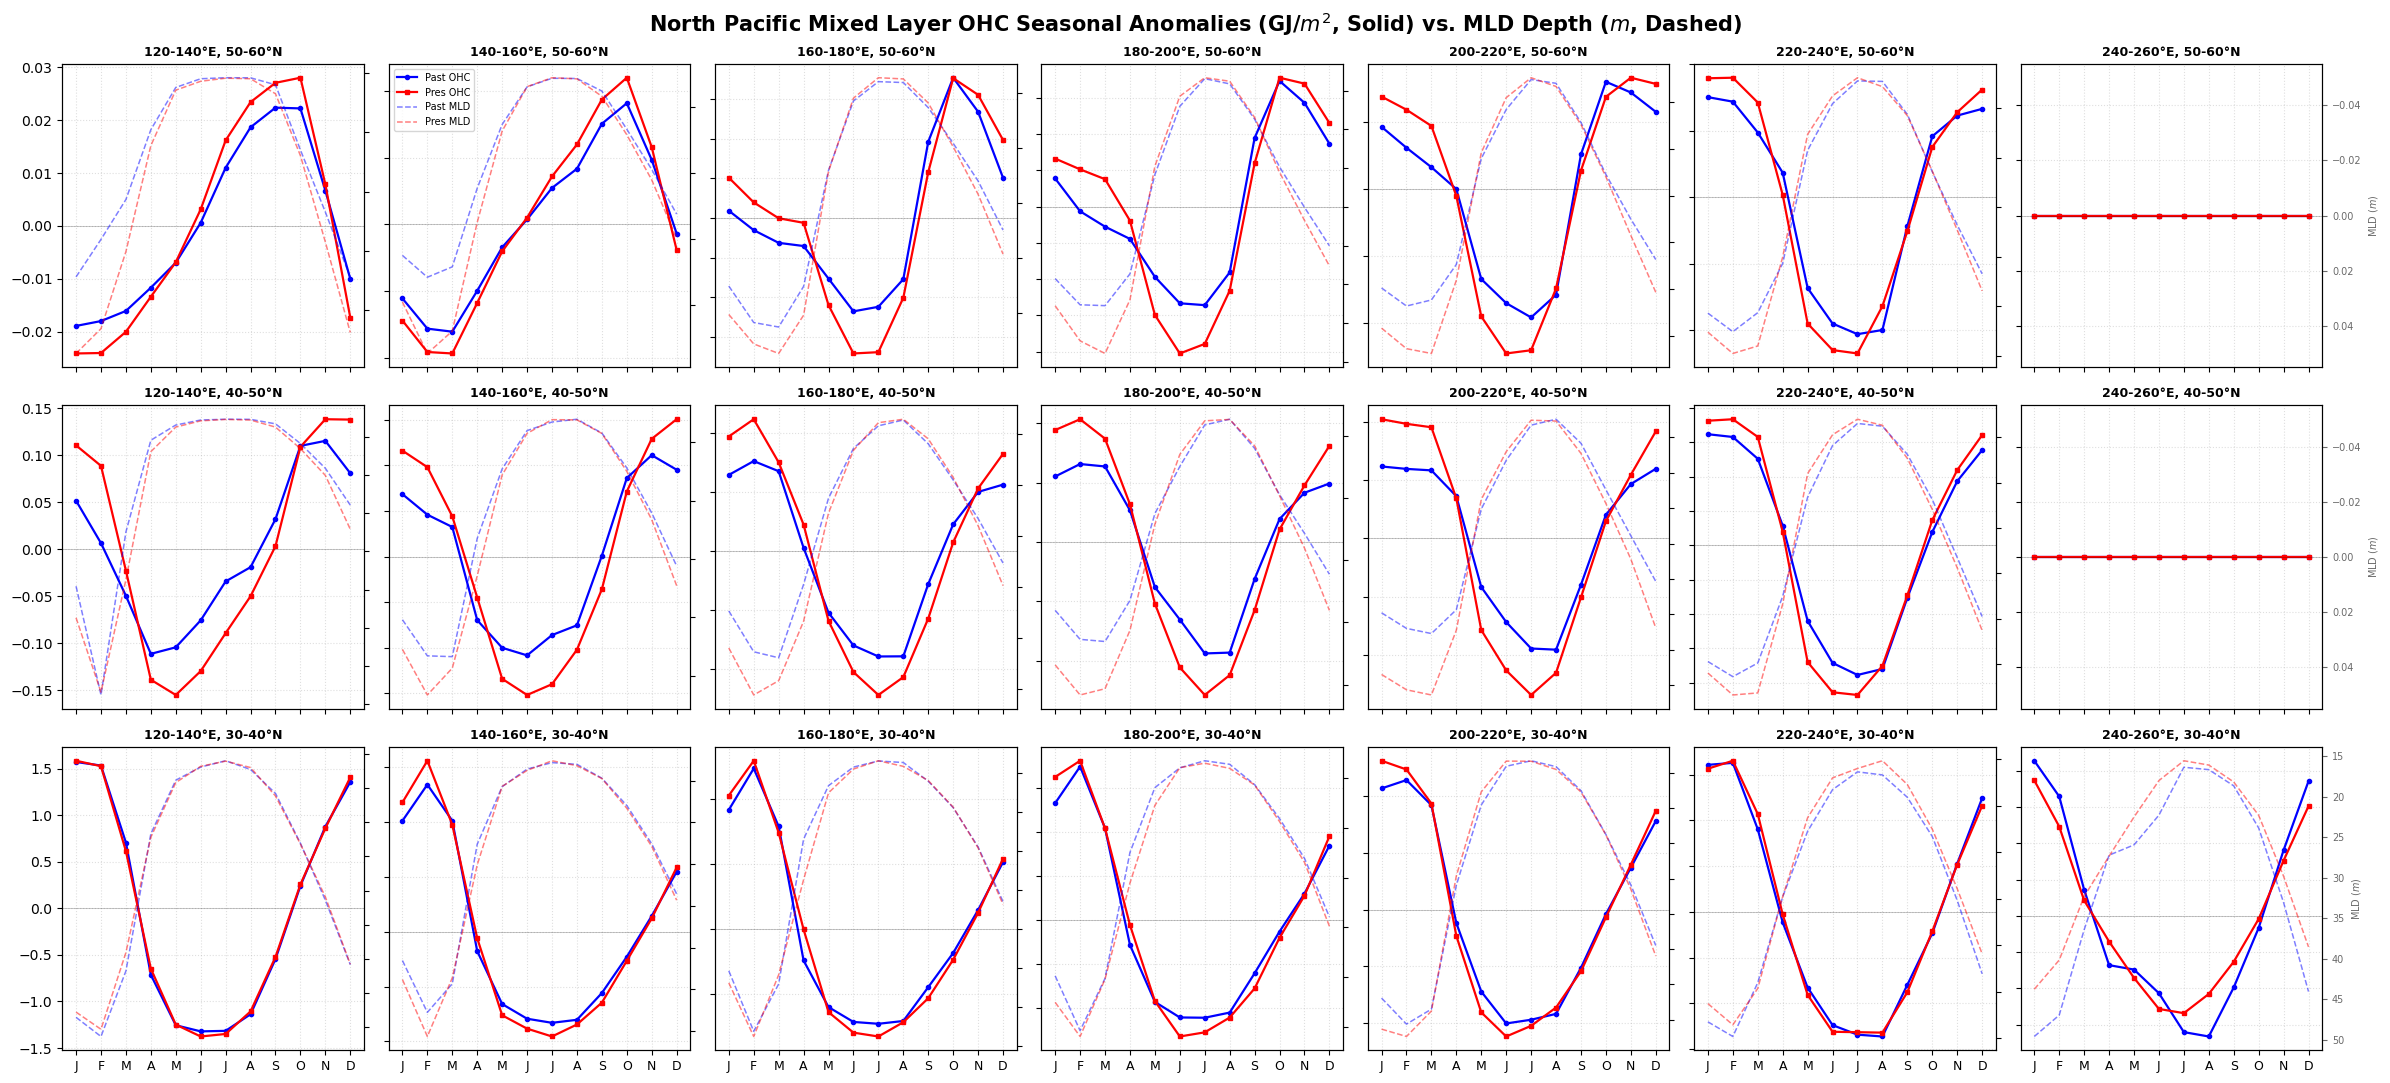

In [28]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================
# 1. Coordinate Boundaries Setup (North Pacific)
# ==========================================
lon_bins_pac = np.arange(120, 280, 20)  # 120, 140, 160, 180, 200, 220, 240, 260
lat_bins_pac = np.arange(30, 70, 10)    # 30, 40, 50, 60

n_lon_pac = len(lon_bins_pac) - 1  # 7 columns
n_lat_pac = len(lat_bins_pac) - 1  # 3 rows

# Setup 3 rows x 7 columns matrix figure (Matches Latitudinal layers)
fig, axes = plt.subplots(nrows=n_lat_pac, ncols=n_lon_pac, figsize=(24, 11), sharex=True)

months_axis = np.arange(1, 13)
month_labels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

print(">>> Generating Mosaic Box Seasonal Cycles for North Pacific (MLD-bounded)...")

# 2. Loop through Latitude layers (Top rows = Higher Latitudes)
for r_idx in range(n_lat_pac):
    # Invert index so row 0 plots 50-60N and row 2 plots 30-40N
    lat_min = lat_bins_pac[n_lat_pac - 1 - r_idx]
    lat_max = lat_bins_pac[n_lat_pac - r_idx]
    
    # Loop through Longitude bins (Left to Right)
    for c_idx in range(n_lon_pac):
        lon_min = lon_bins_pac[c_idx]
        lon_max = lon_bins_pac[c_idx + 1]
        
        ax = axes[r_idx, c_idx]
        
        # 2.1 Slice Area Box for MLD OHC Climatology Grids
        box_past = clim_past_pac.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
        box_pres = clim_present_pac.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
        
        # 2.2 Spatial Mean with Latitude Weighting (Guard Landmask)
        # Check if the entire sliced slice is missing or empty
        if box_past.size == 0 or np.isnan(box_past.values).all():
            ax.set_facecolor('lightgray')
            ax.text(0.5, 0.5, 'Land', ha='center', va='center', transform=ax.transAxes, color='gray', fontsize=10, weight='bold')
            continue
            
        weights_past = np.cos(np.deg2rad(box_past['lat']))
        weights_pres = np.cos(np.deg2rad(box_pres['lat']))
        
        # OHC Time-series calculation (Scaled to GJ/m^2)
        ts_past = box_past.weighted(weights_past).mean(dim=['lat', 'lon'], skipna=True).load() / 1e9
        ts_pres = box_pres.weighted(weights_pres).mean(dim=['lat', 'lon'], skipna=True).load() / 1e9
        
        # Extract relative seasonal anomalies to evaluate pure structural asymmetry phase changes
        anom_past = ts_past - ts_past.mean()
        anom_pres = ts_pres - ts_pres.mean()
        
        # -------------------------------------------------------------
        # Secondary Y-Axis for Dynamic MLD Depth Seasonality Tracking
        # -------------------------------------------------------------
        ax_mld = ax.twinx()
        
        # Extract matching regional MLD depth slices from the base 3D files computed prior
        mld_box_past = ds_past['somxl030'].sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
        mld_box_pres = ds_present['somxl030'].sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
        
        # 12-month climatology and spatial mean for dynamic depth maps
        mld_ts_past = mld_box_past.groupby('time_counter.month').mean(dim='time_counter').weighted(weights_past).mean(dim=['lat', 'lon'], skipna=True).load()
        mld_ts_pres = mld_box_pres.groupby('time_counter.month').mean(dim='time_counter').weighted(weights_pres).mean(dim=['lat', 'lon'], skipna=True).load()
        
        # 2.3 Plotting Curves
        # Solid lines: OHC anomalies
        line1 = ax.plot(months_axis, anom_past, marker='o', markersize=3, color='blue', linewidth=1.6, label='Past OHC')
        line2 = ax.plot(months_axis, anom_pres, marker='s', markersize=3, color='red', linewidth=1.6, label='Pres OHC')
        ax.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
        
        # Dashed lines: MLD Absolute depths (Facing downwards to mimic ocean boundary)
        line3 = ax_mld.plot(months_axis, mld_ts_past, color='blue', linestyle='--', linewidth=1.1, alpha=0.5, label='Past MLD')
        line4 = ax_mld.plot(months_axis, mld_ts_pres, color='red', linestyle='--', linewidth=1.1, alpha=0.5, label='Pres MLD')
        ax_mld.invert_yaxis() # Depth increases downwards
        
        # Formatting individual mini subplots
        ax.set_title(f"{lon_min}-{lon_max}°E, {lat_min}-{lat_max}°N", fontsize=9, weight='bold')
        ax.grid(True, linestyle=':', alpha=0.4)
        ax.set_xticks(months_axis)
        
        # Labels and Axis control to prevent overlapping clutter
        if c_idx != 0:
            ax.set_yticklabels([]) # Hide OHC ticks except leftmost column
        if c_idx != n_lon_pac - 1:
            ax_mld.set_yticklabels([]) # Hide MLD ticks except rightmost column
        else:
            ax_mld.set_ylabel('MLD ($m$)', fontsize=7, color='dimgray')
            ax_mld.tick_params(axis='y', labelsize=7, colors='dimgray')
            
        if r_idx == n_lat_pac - 1:
            ax.set_xticklabels(month_labels, fontsize=9)
            
        # Add a unified legend to the topmost valid oceanic block (typically Gulf of Alaska/Kuril zone)
        if r_idx == 0 and c_idx == 1:
            all_lines = line1 + line2 + line3 + line4
            labels = [l.get_label() for l in all_lines]
            # alpha=0.8을 framealpha=0.8로 수정 (수정된 라인)
            ax.legend(all_lines, labels, fontsize=7, loc='upper left', frameon=True, framealpha=0.8)

plt.suptitle('North Pacific Mixed Layer OHC Seasonal Anomalies (GJ/$m^2$, Solid) vs. MLD Depth ($m$, Dashed)', fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

>>> Generating Mosaic Box Seasonal Cycles for North Atlantic (MLD-bounded)...
    [Detected longitude format style: -180 to 180]


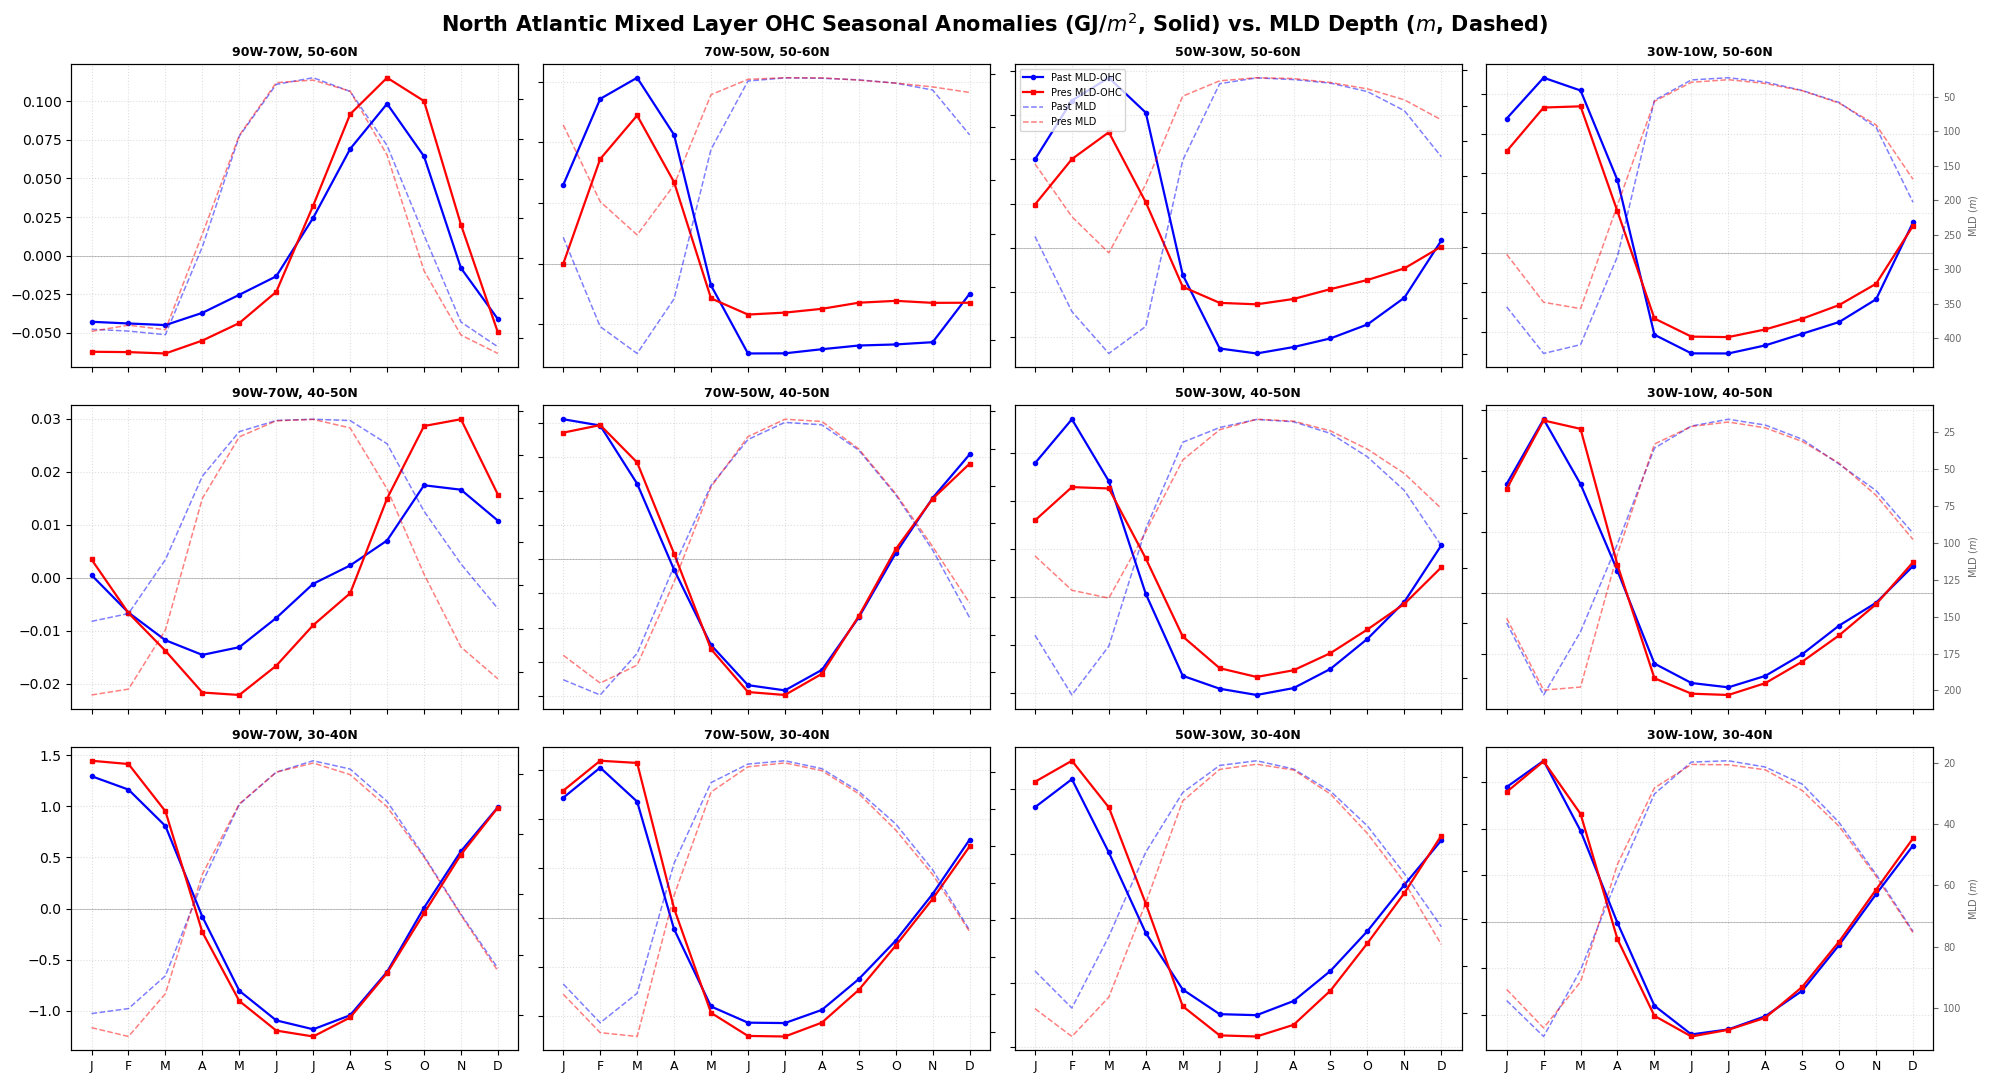

In [29]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================
# 1. Coordinate Boundaries Setup (North Atlantic)
# ==========================================
# Automatically detect if the coordinates on disk use -180 to 180 format or 0 to 360
sample_lon_val = float(clim_past_atl['lon'].values[0])
is_180_format = sample_lon_val < 0 or any(clim_past_atl['lon'].values < 0)

# Standard 0-360 standard bin edges for reference boundary framework
lon_bins_atl = np.arange(270, 370, 20)  # 270, 290, 310, 330, 350, 370 (90W to 10E)
lat_bins_atl = np.arange(30, 70, 10)    # 30, 40, 50, 60

n_lon_atl = len(lon_bins_atl) - 1  # 5 columns
n_lat_atl = len(lat_bins_atl) - 1  # 3 rows

fig, axes = plt.subplots(nrows=n_lat_atl, ncols=n_lon_atl, figsize=(20, 11), sharex=True)
months_axis = np.arange(1, 13)
month_labels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

print(f">>> Generating Mosaic Box Seasonal Cycles for North Atlantic (MLD-bounded)...")
print(f"    [Detected longitude format style: {'-180 to 180' if is_180_format else '0 to 360'}]")

# 2. Loop through Latitude layers (Top rows = Higher Latitudes)
for r_idx in range(n_lat_atl):
    lat_min = lat_bins_atl[n_lat_atl - 1 - r_idx]
    lat_max = lat_bins_atl[n_lat_atl - r_idx]
    
    # Loop through Longitude bins (Left to Right)
    for c_idx in range(n_lon_atl):
        lon_min = lon_bins_atl[c_idx]
        lon_max = lon_bins_atl[c_idx + 1]
        if lon_max > 360: 
            lon_max = 360
            
        ax = axes[r_idx, c_idx]
        
        # 2.1 Coordinate System Adapter mapping for accurate slicing
        if is_180_format:
            slice_lon_min = lon_min - 360 if lon_min > 180 else lon_min
            slice_lon_max = lon_max - 360 if lon_max > 180 else lon_max
            box_lon_min = min(slice_lon_min, slice_lon_max)
            box_lon_max = max(slice_lon_min, slice_lon_max)
        else:
            box_lon_min = lon_min
            box_lon_max = lon_max
            
        # Slice Area Box for Atlantic MLD OHC Climatology Grids
        box_past = clim_past_atl.sel(lon=slice(box_lon_min, box_lon_max), lat=slice(lat_min, lat_max))
        box_pres = clim_present_atl.sel(lon=slice(box_lon_min, box_lon_max), lat=slice(lat_min, lat_max))
        
        # 2.2 Spatial Mean with Latitude Weighting (Guard Landmask / Gulf of Mexico edges)
        if box_past.size == 0 or np.isnan(box_past.values).all():
            ax.set_facecolor('lightgray')
            disp_lon_min = f"{360-lon_min}W" if lon_min > 180 else f"{lon_min}E"
            disp_lon_max = f"{360-lon_max}W" if lon_max > 180 else f"{lon_max}E"
            ax.set_title(f"{disp_lon_min}-{disp_lon_max}, {lat_min}-{lat_max}N", fontsize=8, color='gray')
            ax.text(0.5, 0.5, 'Land', ha='center', va='center', transform=ax.transAxes, color='gray', fontsize=10, weight='bold')
            continue
            
        weights_past = np.cos(np.deg2rad(box_past['lat']))
        weights_pres = np.cos(np.deg2rad(box_pres['lat']))
        
        # OHC Time-series calculation (Scaled to GJ/m^2)
        ts_past = box_past.weighted(weights_past).mean(dim=['lat', 'lon'], skipna=True).load() / 1e9
        ts_pres = box_pres.weighted(weights_pres).mean(dim=['lat', 'lon'], skipna=True).load() / 1e9
        
        # Extract relative seasonal anomalies
        anom_past = ts_past - ts_past.mean()
        anom_pres = ts_pres - ts_pres.mean()
        
        # -------------------------------------------------------------
        # Secondary Y-Axis for Dynamic Atlantic MLD Depth Tracking
        # -------------------------------------------------------------
        ax_mld = ax.twinx()
        
        # Extract matching regional Atlantic MLD slices from the base 3D files (ds_past_atl_final/ds_present_atl_final)
        mld_box_past = ds_past_atl_final['somxl030'].sel(lon=slice(box_lon_min, box_lon_max), lat=slice(lat_min, lat_max))
        mld_box_pres = ds_present_atl_final['somxl030'].sel(lon=slice(box_lon_min, box_lon_max), lat=slice(lat_min, lat_max))
        
        # 12-month climatology and spatial mean for dynamic MLD maps
        mld_ts_past = mld_box_past.groupby('time_counter.month').mean(dim='time_counter').weighted(weights_past).mean(dim=['lat', 'lon'], skipna=True).load()
        mld_ts_pres = mld_box_pres.groupby('time_counter.month').mean(dim='time_counter').weighted(weights_pres).mean(dim=['lat', 'lon'], skipna=True).load()
        
        # 2.3 Plotting Curves
        # Solid lines: OHC anomalies
        line1 = ax.plot(months_axis, anom_past, marker='o', markersize=3, color='blue', linewidth=1.6, label='Past MLD-OHC')
        line2 = ax.plot(months_axis, anom_pres, marker='s', markersize=3, color='red', linewidth=1.6, label='Pres MLD-OHC')
        ax.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
        
        # Dashed lines: MLD Absolute depths (Facing downwards)
        line3 = ax_mld.plot(months_axis, mld_ts_past, color='blue', linestyle='--', linewidth=1.1, alpha=0.5, label='Past MLD')
        line4 = ax_mld.plot(months_axis, mld_ts_pres, color='red', linestyle='--', linewidth=1.1, alpha=0.5, label='Pres MLD')
        ax_mld.invert_yaxis()  # Ocean standard inversion
        
        # Subplot Titles with traditional Atlantic notations (W/E labels)
        disp_lon_min = f"{360-lon_min}W" if lon_min > 180 else f"{lon_min}E"
        disp_lon_max = f"{360-lon_max}W" if lon_max > 180 else f"{lon_max}E"
        ax.set_title(f"{disp_lon_min}-{disp_lon_max}, {lat_min}-{lat_max}N", fontsize=9, weight='bold')
        ax.grid(True, linestyle=':', alpha=0.4)
        ax.set_xticks(months_axis)
        
        # Axis label pruning to maintain clean matrix framework
        if c_idx != 0:
            ax.set_yticklabels([])  # Hide OHC ticks except leftmost column
        if c_idx != n_lon_atl - 1:
            ax_mld.set_yticklabels([])  # Hide MLD ticks except rightmost column
        else:
            ax_mld.set_ylabel('MLD ($m$)', fontsize=7, color='dimgray')
            ax_mld.tick_params(axis='y', labelsize=7, colors='dimgray')
            
        if r_idx == n_lat_atl - 1:
            ax.set_xticklabels(month_labels, fontsize=9)
            
        # Unified Legend placement (Locked onto the first valid offshore grid box)
        if r_idx == 0 and c_idx == 2:
            all_lines = line1 + line2 + line3 + line4
            labels = [l.get_label() for l in all_lines]
            # Bug Fixed: framealpha used instead of alpha to pass strict Matplotlib checking
            ax.legend(all_lines, labels, fontsize=7, loc='upper left', frameon=True, framealpha=0.8)

plt.suptitle('North Atlantic Mixed Layer OHC Seasonal Anomalies (GJ/$m^2$, Solid) vs. MLD Depth ($m$, Dashed)', fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [33]:
import numpy as np
import xarray as xr

def calculate_gridwise_r2(clim_grid, ny, nx):
    """
    Computes grid-point R2 tracking how well H1 + H2 fourier curve explains the actual cycle.
    """
    # Shape: (12, lat, lon) -> (12, lat*lon)
    data_3d = clim_grid.values
    data_flat = data_3d.reshape(12, -1)
    
    # Track land mask
    land_mask = np.isnan(data_flat).all(axis=0)
    data_filled = np.nan_to_num(data_flat, nan=0.0)
    
    # 1. Total Sum of Squares (SST): Sum of (y_actual - y_mean)^2
    grid_means = data_filled.mean(axis=0)  # A0 mean state per pixel
    sst = np.sum((data_filled - grid_means)**2, axis=0)
    
    # 2. Fourier Reconstruction (A0 + H1 + H2)
    dft_coeffs = np.fft.fft(data_filled, axis=0)
    
    # Time axis arrays matching the 12 months (t = 1, 2, ..., 12)
    t = np.arange(1, 13)[:, np.newaxis]
    omega = 2 * np.pi / 12.0
    
    # Extract components
    h1 = dft_coeffs[1, :] * (2.0 / 12.0)
    h2 = dft_coeffs[2, :] * (2.0 / 12.0)
    
    A1, A2 = np.abs(h1), np.abs(h2)
    phi1, phi2 = -np.angle(h1), -np.angle(h2)
    
    # Reconstruct the 12-month fitted curve per pixel
    fit_curve = (grid_means + 
                 A1 * np.cos(omega * t - phi1) + 
                 A2 * np.cos(2 * omega * t - phi2))
    
    # 3. Residual Sum of Squares (SSR): Sum of (y_actual - y_fitted)^2
    ssr = np.sum((data_filled - fit_curve)**2, axis=0)
    
    # 4. Calculate R2 = 1 - (SSR / SST)
    with np.errstate(divide='ignore', invalid='ignore'):
        r2 = 1.0 - (ssr / sst)
        # Handle edge cases where variance is exactly zero
        r2[sst == 0] = np.nan 
        
    # Re-apply ocean mask
    r2[land_mask] = np.nan
    
    return r2.reshape(ny, nx)

print(">>> Computing grid-wise R2 maps for Present Period (2015-2024) based on MLD OHC...")

# Fixed: Mapped explicitly using the updated MLD grid parameters from previous steps
r2_map_pac = calculate_gridwise_r2(clim_present_pac, ny_pac, nx_pac)
r2_map_atl = calculate_gridwise_r2(clim_present_atl, ny_atl, nx_atl)

print(f"  - Pacific MLD-OHC R2  [Max: {np.nanmax(r2_map_pac):.3f} | Min: {np.nanmin(r2_map_pac):.3f}]")
print(f"  - Atlantic MLD-OHC R2 [Max: {np.nanmax(r2_map_atl):.3f} | Min: {np.nanmin(r2_map_atl):.3f}]")

>>> Computing grid-wise R2 maps for Present Period (2015-2024) based on MLD OHC...
  - Pacific MLD-OHC R2  [Max: 0.731 | Min: 0.171]
  - Atlantic MLD-OHC R2 [Max: 0.731 | Min: 0.122]



>>> Plotting 1x2 Grid-wise R2 Matrix for Pacific and Atlantic (Robust Dimension Match)...


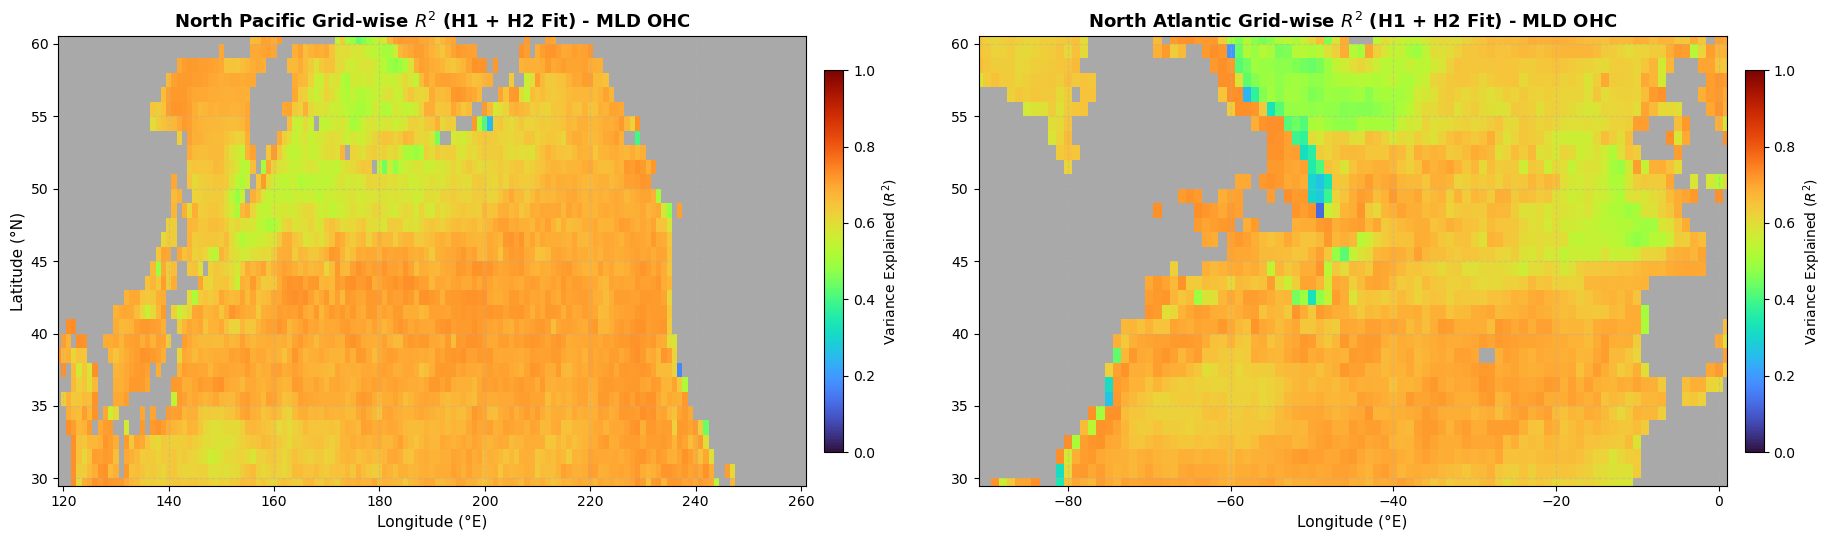

In [36]:
import matplotlib.pyplot as plt
import numpy as np

print("\n>>> Plotting 1x2 Grid-wise R2 Matrix for Pacific and Atlantic (Robust Dimension Match)...")

# Main Figure Framing (1 row, 2 columns)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(19, 5.5))

r2_cmap = 'turbo'  # Transition scale for 0.0 to 1.0 mapping resolution

# -----------------------------------------------------------------
# Panel A: North Pacific Grid-wise R2 (데이터셋 자체 좌표계 직접 추출)
# -----------------------------------------------------------------
ax0 = axes[0]
# [CRITICAL FIX] clim_present_pac에서 직접 실시간 좌표를 뽑아 그리드를 생성합니다.
lon_p_actual = clim_present_pac['lon'].values
lat_p_actual = clim_present_pac['lat'].values
lon_grid_pac_real, lat_grid_pac_real = np.meshgrid(lon_p_actual, lat_p_actual)

mesh0 = ax0.pcolormesh(lon_grid_pac_real, lat_grid_pac_real, r2_map_pac, cmap=r2_cmap, vmin=0.0, vmax=1.0, shading='auto')
ax0.set_title('North Pacific Grid-wise $R^2$ (H1 + H2 Fit) - MLD OHC', fontsize=13, weight='bold')
ax0.set_xlabel('Longitude (°E)', fontsize=11)
ax0.set_ylabel('Latitude (°N)', fontsize=11)
ax0.set_xlim(lon_p_actual.min(), lon_p_actual.max())
ax0.set_ylim(lat_p_actual.min(), lat_p_actual.max())

cbar0 = fig.colorbar(mesh0, ax=ax0, orientation='vertical', pad=0.02, shrink=0.85)
cbar0.set_label('Variance Explained ($R^2$)', fontsize=10)

# -----------------------------------------------------------------
# Panel B: North Atlantic Grid-wise R2 (데이터셋 자체 좌표계 직접 추출)
# -----------------------------------------------------------------
ax1 = axes[1]
# [CRITICAL FIX] clim_present_atl에서 직접 실시간 좌표를 뽑아 그리드를 생성합니다.
lon_a_actual = clim_present_atl['lon'].values
lat_a_actual = clim_present_atl['lat'].values
lon_grid_atl_real, lat_grid_atl_real = np.meshgrid(lon_a_actual, lat_a_actual)

mesh1 = ax1.pcolormesh(lon_grid_atl_real, lat_grid_atl_real, r2_map_atl, cmap=r2_cmap, vmin=0.0, vmax=1.0, shading='auto')
ax1.set_title('North Atlantic Grid-wise $R^2$ (H1 + H2 Fit) - MLD OHC', fontsize=13, weight='bold')
ax1.set_xlabel('Longitude (°E)', fontsize=11)
ax1.set_xlim(lon_a_actual.min(), lon_a_actual.max())
ax1.set_ylim(lat_a_actual.min(), lat_a_actual.max())

cbar1 = fig.colorbar(mesh1, ax=ax1, orientation='vertical', pad=0.02, shrink=0.85)
cbar1.set_label('Variance Explained ($R^2$)', fontsize=10)

# Standardize axis decorations across both panels
for ax in axes:
    ax.set_facecolor('darkgray')  # Keeps land masks beautifully clean
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()